### Deep learning model training.
#### Top accuracy(patch_size = 448)   
|model|miou|oa|update_time|    
|----|----|----|----|   
|UNet|88.9%|93.1%|20260428|    
|deeplabv3plus_mb2|90.9%|95.7%|20260428|    
|UNet_att|90.8%|95.3%|20260428|    
|SwinUNet|90.3%|94.7%|20260428|    

#### Top accuracy(patch_size = 512)   

|model|miou|oa|update_time|    
|----|----|----|----|   
|UNet|92.1%|95.7%|2026.4.7|    
|deeplabv3plus_mb2|93.4%|97.2%|2026.4.8|    
|UNet_att|93.0%|96.8%|2026.4.7|    
|swin_unet|92.7%|96.5%|2026.5.4|    

#### Note: 
1. when use unet, the bn parameters should be frozen using model.eval().  


In [ ]:
import time
import torch
import random
import numpy as np 
import pandas as pd 
import torch.nn as nn
from glob import glob
from notebooks import config
import matplotlib.pyplot as plt
from pyrsimg import imsShow
from utils.utils import read_scenes
from utils.data_loader import SceneArraySet, PatchPathSet
from utils.data_aug import GaussianNoise
import torch.nn.functional as F
from torchmetrics.classification import MulticlassJaccardIndex, BinaryAccuracy
from torchvision.transforms import v2
from model import unet, unet_att, deeplabv3plus_mobilev2, swin_unet, watnet
from model import unet_timm, unet_swin_timm


In [ ]:
patch_size = 512        ## patch size setting
patch_resize = None     ## patch resize setting
learning_rate = 1e-4     
batch_size = 8   
device = torch.device('cuda:0')  
model_name = 'model_trained'  ## model name for saving

In [ ]:
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
print(f'train_scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali_patch_{patch_size}: {len(paths_valset)}')


train_scenes: 172
vali_patch_512: 217


### dataset loading

In [ ]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, paths_truth_tra) 
scene_truth_ls =  list(zip(scenes_arr, truths_arr))
scene_truth_ls = [np.concatenate([scene, truth[:, :, np.newaxis]], axis=-1) 
                                for scene, truth in scene_truth_ls] 


In [ ]:
transforms_tra = v2.Compose([
      v2.ToImage(),
      v2.RandomCrop(size=(patch_size, patch_size), padding = 50, fill=0),
      v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.3),
      v2.RandomHorizontalFlip(p=0.3),
      v2.RandomVerticalFlip(p=0.3),
      GaussianNoise(mean=0, sigma_max=0.1, p=0.3)    
       ])
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])


In [ ]:
tra_dset = SceneArraySet(scene_truth_list = scene_truth_ls, transforms = transforms_tra)
val_dset = PatchPathSet(paths_valset=paths_valset, transforms=transforms_val)
### Create DataLoader
tra_loader = torch.utils.data.DataLoader(tra_dset, batch_size=batch_size, 
                                         shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dset, batch_size=batch_size, num_workers=5) 


#### Model training

In [ ]:
### check model
model = unet(num_bands=6)
# model = watnet(num_bands=6)
# model = unet_att(num_bands=6)
# model = deeplabv3plus_mobilev2(num_bands=6)
# model = swin_unet(img_size=512, num_bands=6, window_size=8)
## model with pretrained 
# model = unet_timm(num_bands=6, 
#                    backbone_name='efficientnet_b0', 
#                   # backbone_name='mobilenetv3_large_100',
#                   #  backbone_name='resnet50',
#                    pretrained=True)
# model = unet_swin_timm(num_bands=6, 
#                          img_size = 512, 
#                          backbone_name='swinv2_base_window8_256',
#                          pretrained=True)


In [ ]:
input_tensor = torch.randn(2, 6, 512, 512)  
output = model(input_tensor) 
print(output.shape)


torch.Size([2, 1, 512, 512])


In [ ]:
### create loss and optimizer
bce_loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, \
#                                       mode='max', 
#                                       factor=0.5, 
#                                       patience=10,
#                                       min_lr=1e-5)


In [ ]:
sam_index = random.randrange(len(val_dset))
patch_val, truth_val = val_dset[sam_index]
def show_result(model, patch, truth):
    model.eval()
    device = next(model.parameters()).device
    patch, truth = patch.unsqueeze(0).to(device), truth.to(device)
    pred = model(patch) 
    ## convert to numpy and plot
    patch = patch[0].to('cpu').detach().numpy().transpose(1,2,0)            
    pred = pred[0].to('cpu').detach().numpy()
    truth = truth.to('cpu').detach().numpy()
    imsShow([patch, pred, truth],   
            clip_list = (2,0,0),
            img_name_list=['patch', 'pred', 'truth'], 
            color_bands_list=([3,2,2], 0, 0),                    
            figsize=(9, 2.5))
    plt.tight_layout() 
    plt.show()  

In [ ]:
'''------train loops------'''
def train_loops(model, loss_fn, 
                    optimizer, 
                    tra_loader, 
                    val_loader,  
                    epoches, 
                    device, 
                    lr_scheduler=None):
    loss_tra_loops, miou_tra_loops, oa_tra_loops = [], [], []
    loss_val_loops, miou_val_loops, oa_val_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    best_miou = 0.80
    epoches_i = []
    for epoch in range(epoches):
        start = time.time()
        loss_tra, loss_val = 0, 0
        '''-----train the model-----'''
        oa_tra = BinaryAccuracy().to(device)
        miou_tra = MulticlassJaccardIndex(num_classes=2, average="macro").to(device)
        model.train()   # training mode for dropout and batchnorm
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            pred = (F.sigmoid(pred) > 0.5).float()
            miou_tra.update(pred, y_batch.long())
            oa_tra.update(pred, y_batch.long())
            loss_tra += loss.item()
        miou_tra_global = miou_tra.compute()
        oa_tra_global = oa_tra.compute()
        loss_tra_global = loss_tra/size_tra_loader
        miou_tra.reset(); oa_tra.reset()

        '''----- validation the model: time consuming -----'''
        oa_val = BinaryAccuracy().to(device)
        miou_val = MulticlassJaccardIndex(num_classes=2, average="macro").to(device)
        model.eval()
        if epoch > 500 and (epoch+1) % 2 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                with torch.no_grad():
                    pred = model(x_batch)
                    loss = loss_fn(pred, y_batch)
                pred = (F.sigmoid(pred) > 0.5).float()
                miou_val.update(pred, y_batch.long())
                oa_val.update(pred, y_batch.long())
                loss_val += loss.item()
            miou_val_global = miou_val.compute()
            oa_val_global = oa_val.compute()
            loss_val_global = loss_val/size_val_loader
            miou_val.reset(); oa_val.reset()
            loss_tra_loops.append(loss_tra_global); miou_tra_loops.append(miou_tra_global.item()); oa_tra_loops.append(oa_tra_global.item())
            loss_val_loops.append(loss_val_global); miou_val_loops.append(miou_val_global.item()); oa_val_loops.append(oa_val_global.item())
            epoches_i.append(epoch)
            print(f'Ep{epoch}: tra-> Loss:{loss_tra_global:.3f},Oa:{oa_tra_global:.3f},Miou:{miou_tra_global:.3f}, '
                    f'val-> Loss:{loss_val_global:.4f},Oa:{oa_val_global:.4f}, Miou:{miou_val_global:.4f},time:{time.time()-start:.1f}s')
            ## save the best model
            if miou_val_global.item() > best_miou:
                best_miou = miou_val_global.item()       ## update best miou
                torch.save(model.state_dict(), f'model/trained/{model_name}_0{str(round(best_miou*10000))}.pth')
        else: 
            print(f'Ep{epoch}: tra-> Loss:{loss_tra_global:.3f},Oa:{oa_tra_global:.3f},Miou:{miou_tra_global:.3f}, \
                                time:{time.time()-start:.1f}s')
        if lr_scheduler: lr_scheduler.step(miou_tra_global)    ## if use lr_scheduler like ReduceLROnPlateau
        if (epoch+1)%20 == 0:
            sam_index = random.randrange(len(val_dset))
            patch_val, truth_val = val_dset[sam_index]
            show_result(model=model, patch=patch_val, truth=truth_val)
    metrics = {'epoch':epoches_i, 'tra_loss':loss_tra_loops, 'tra_oa': oa_tra_loops, 'tra_miou': miou_tra_loops,
                'val_loss': loss_val_loops, 'val_oa': oa_val_loops, 'val_miou': miou_val_loops}
    return metrics 

Ep0: tra-> Loss:0.474,Oa:0.858,Miou:0.548,                                 time:3.7s
Ep1: tra-> Loss:0.354,Oa:0.909,Miou:0.664,                                 time:3.5s
Ep2: tra-> Loss:0.301,Oa:0.926,Miou:0.710,                                 time:3.5s
Ep3: tra-> Loss:0.280,Oa:0.933,Miou:0.704,                                 time:3.7s
Ep4: tra-> Loss:0.255,Oa:0.923,Miou:0.699,                                 time:3.5s
Ep5: tra-> Loss:0.231,Oa:0.940,Miou:0.757,                                 time:3.4s
Ep6: tra-> Loss:0.220,Oa:0.944,Miou:0.735,                                 time:3.5s
Ep7: tra-> Loss:0.196,Oa:0.944,Miou:0.763,                                 time:3.5s
Ep8: tra-> Loss:0.207,Oa:0.932,Miou:0.712,                                 time:3.6s
Ep9: tra-> Loss:0.183,Oa:0.944,Miou:0.752,                                 time:3.6s
Ep10: tra-> Loss:0.174,Oa:0.948,Miou:0.766,                                 time:3.6s
Ep11: tra-> Loss:0.173,Oa:0.943,Miou:0.761,                     

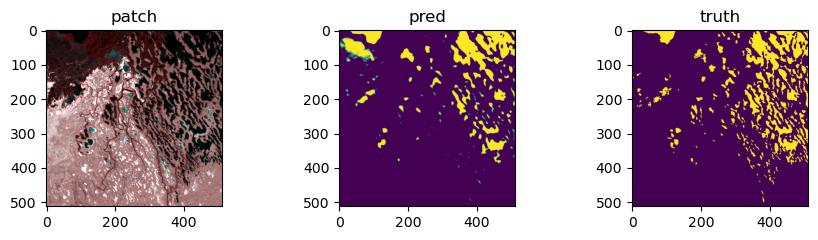

Ep20: tra-> Loss:0.141,Oa:0.953,Miou:0.779,                                 time:3.6s
Ep21: tra-> Loss:0.141,Oa:0.954,Miou:0.794,                                 time:3.7s
Ep22: tra-> Loss:0.136,Oa:0.951,Miou:0.775,                                 time:3.5s
Ep23: tra-> Loss:0.134,Oa:0.957,Miou:0.806,                                 time:3.7s
Ep24: tra-> Loss:0.116,Oa:0.964,Miou:0.834,                                 time:3.8s
Ep25: tra-> Loss:0.113,Oa:0.959,Miou:0.823,                                 time:3.6s
Ep26: tra-> Loss:0.102,Oa:0.964,Miou:0.849,                                 time:3.6s
Ep27: tra-> Loss:0.117,Oa:0.959,Miou:0.812,                                 time:3.7s
Ep28: tra-> Loss:0.113,Oa:0.960,Miou:0.818,                                 time:3.8s
Ep29: tra-> Loss:0.122,Oa:0.960,Miou:0.833,                                 time:3.5s
Ep30: tra-> Loss:0.111,Oa:0.963,Miou:0.835,                                 time:3.5s
Ep31: tra-> Loss:0.121,Oa:0.955,Miou:0.798,           

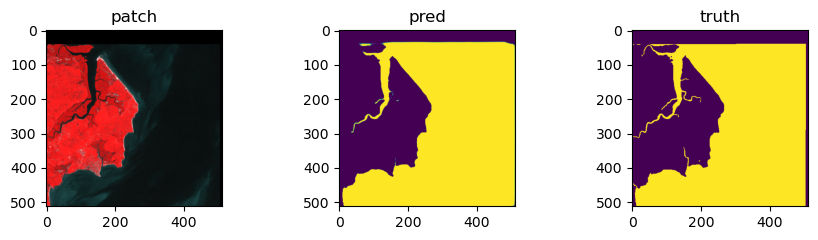

Ep40: tra-> Loss:0.122,Oa:0.959,Miou:0.824,                                 time:3.6s
Ep41: tra-> Loss:0.120,Oa:0.953,Miou:0.792,                                 time:3.5s
Ep42: tra-> Loss:0.103,Oa:0.963,Miou:0.830,                                 time:3.4s
Ep43: tra-> Loss:0.109,Oa:0.961,Miou:0.849,                                 time:3.4s
Ep44: tra-> Loss:0.103,Oa:0.965,Miou:0.841,                                 time:3.5s
Ep45: tra-> Loss:0.098,Oa:0.965,Miou:0.853,                                 time:3.5s
Ep46: tra-> Loss:0.092,Oa:0.967,Miou:0.844,                                 time:3.6s
Ep47: tra-> Loss:0.101,Oa:0.967,Miou:0.841,                                 time:3.5s
Ep48: tra-> Loss:0.090,Oa:0.968,Miou:0.853,                                 time:3.5s
Ep49: tra-> Loss:0.090,Oa:0.967,Miou:0.855,                                 time:3.6s
Ep50: tra-> Loss:0.092,Oa:0.968,Miou:0.852,                                 time:3.5s
Ep51: tra-> Loss:0.106,Oa:0.964,Miou:0.830,           

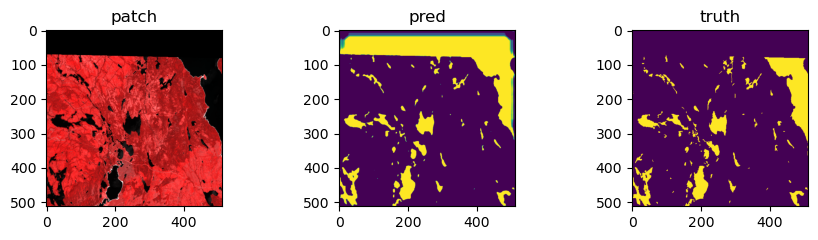

Ep60: tra-> Loss:0.099,Oa:0.964,Miou:0.841,                                 time:3.6s
Ep61: tra-> Loss:0.082,Oa:0.970,Miou:0.850,                                 time:3.5s
Ep62: tra-> Loss:0.098,Oa:0.966,Miou:0.836,                                 time:3.4s
Ep63: tra-> Loss:0.103,Oa:0.963,Miou:0.834,                                 time:3.5s
Ep64: tra-> Loss:0.099,Oa:0.964,Miou:0.846,                                 time:3.4s
Ep65: tra-> Loss:0.080,Oa:0.970,Miou:0.875,                                 time:3.5s
Ep66: tra-> Loss:0.087,Oa:0.968,Miou:0.852,                                 time:3.4s
Ep67: tra-> Loss:0.086,Oa:0.970,Miou:0.854,                                 time:3.6s
Ep68: tra-> Loss:0.088,Oa:0.968,Miou:0.859,                                 time:3.4s
Ep69: tra-> Loss:0.087,Oa:0.970,Miou:0.862,                                 time:3.5s
Ep70: tra-> Loss:0.086,Oa:0.966,Miou:0.831,                                 time:3.5s
Ep71: tra-> Loss:0.083,Oa:0.970,Miou:0.871,           

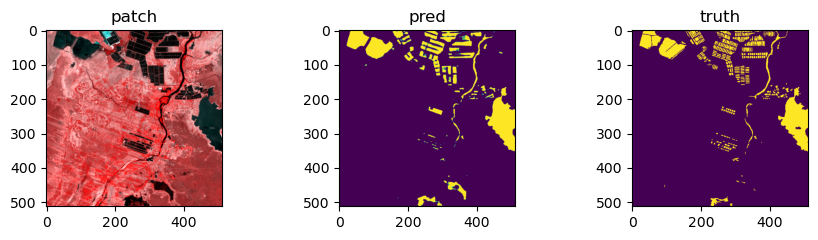

Ep80: tra-> Loss:0.074,Oa:0.972,Miou:0.876,                                 time:3.7s
Ep81: tra-> Loss:0.080,Oa:0.970,Miou:0.865,                                 time:3.5s
Ep82: tra-> Loss:0.078,Oa:0.972,Miou:0.870,                                 time:3.5s
Ep83: tra-> Loss:0.087,Oa:0.969,Miou:0.845,                                 time:3.7s
Ep84: tra-> Loss:0.084,Oa:0.969,Miou:0.860,                                 time:3.6s
Ep85: tra-> Loss:0.079,Oa:0.972,Miou:0.874,                                 time:3.5s
Ep86: tra-> Loss:0.089,Oa:0.969,Miou:0.856,                                 time:3.6s
Ep87: tra-> Loss:0.077,Oa:0.971,Miou:0.867,                                 time:3.5s
Ep88: tra-> Loss:0.085,Oa:0.970,Miou:0.859,                                 time:3.4s
Ep89: tra-> Loss:0.075,Oa:0.973,Miou:0.881,                                 time:3.4s
Ep90: tra-> Loss:0.075,Oa:0.973,Miou:0.869,                                 time:3.5s
Ep91: tra-> Loss:0.081,Oa:0.970,Miou:0.848,           

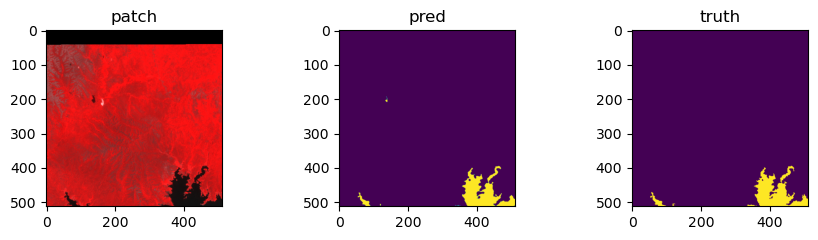

Ep100: tra-> Loss:0.066,Oa:0.976,Miou:0.882,                                 time:3.5s
Ep101: tra-> Loss:0.081,Oa:0.971,Miou:0.864,                                 time:3.5s
Ep102: tra-> Loss:0.072,Oa:0.973,Miou:0.875,                                 time:3.5s
Ep103: tra-> Loss:0.081,Oa:0.971,Miou:0.869,                                 time:3.6s
Ep104: tra-> Loss:0.076,Oa:0.973,Miou:0.878,                                 time:3.4s
Ep105: tra-> Loss:0.080,Oa:0.970,Miou:0.862,                                 time:3.5s
Ep106: tra-> Loss:0.076,Oa:0.972,Miou:0.872,                                 time:3.6s
Ep107: tra-> Loss:0.066,Oa:0.975,Miou:0.883,                                 time:3.6s
Ep108: tra-> Loss:0.067,Oa:0.976,Miou:0.893,                                 time:3.6s
Ep109: tra-> Loss:0.071,Oa:0.974,Miou:0.883,                                 time:3.6s
Ep110: tra-> Loss:0.070,Oa:0.974,Miou:0.887,                                 time:3.6s
Ep111: tra-> Loss:0.084,Oa:0.969,Miou:0.862

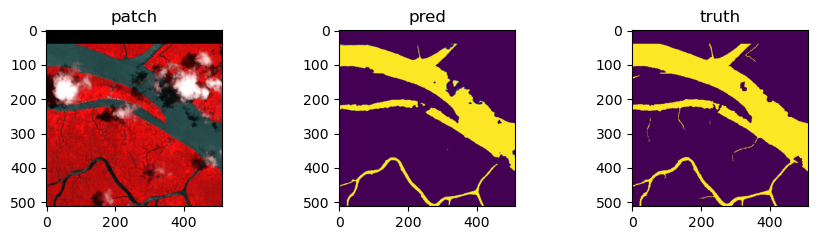

Ep120: tra-> Loss:0.072,Oa:0.977,Miou:0.898,                                 time:3.6s
Ep121: tra-> Loss:0.069,Oa:0.975,Miou:0.882,                                 time:3.7s
Ep122: tra-> Loss:0.068,Oa:0.975,Miou:0.881,                                 time:3.6s
Ep123: tra-> Loss:0.062,Oa:0.978,Miou:0.894,                                 time:3.4s
Ep124: tra-> Loss:0.067,Oa:0.975,Miou:0.879,                                 time:3.5s
Ep125: tra-> Loss:0.074,Oa:0.974,Miou:0.888,                                 time:3.5s
Ep126: tra-> Loss:0.068,Oa:0.977,Miou:0.890,                                 time:3.5s
Ep127: tra-> Loss:0.079,Oa:0.971,Miou:0.875,                                 time:3.5s
Ep128: tra-> Loss:0.084,Oa:0.969,Miou:0.845,                                 time:3.5s
Ep129: tra-> Loss:0.072,Oa:0.973,Miou:0.863,                                 time:3.5s
Ep130: tra-> Loss:0.075,Oa:0.972,Miou:0.876,                                 time:3.5s
Ep131: tra-> Loss:0.082,Oa:0.968,Miou:0.851

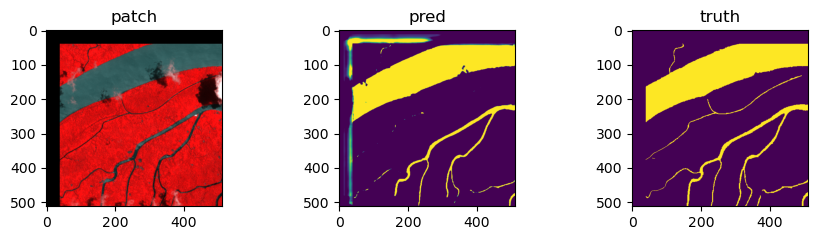

Ep140: tra-> Loss:0.069,Oa:0.975,Miou:0.880,                                 time:3.6s
Ep141: tra-> Loss:0.064,Oa:0.976,Miou:0.886,                                 time:3.5s
Ep142: tra-> Loss:0.069,Oa:0.974,Miou:0.872,                                 time:3.5s
Ep143: tra-> Loss:0.070,Oa:0.972,Miou:0.856,                                 time:3.5s
Ep144: tra-> Loss:0.068,Oa:0.975,Miou:0.894,                                 time:3.6s
Ep145: tra-> Loss:0.057,Oa:0.979,Miou:0.906,                                 time:3.6s
Ep146: tra-> Loss:0.064,Oa:0.977,Miou:0.886,                                 time:3.5s
Ep147: tra-> Loss:0.080,Oa:0.972,Miou:0.861,                                 time:3.6s
Ep148: tra-> Loss:0.090,Oa:0.967,Miou:0.849,                                 time:3.6s
Ep149: tra-> Loss:0.074,Oa:0.970,Miou:0.871,                                 time:3.5s
Ep150: tra-> Loss:0.078,Oa:0.971,Miou:0.865,                                 time:3.4s
Ep151: tra-> Loss:0.077,Oa:0.971,Miou:0.867

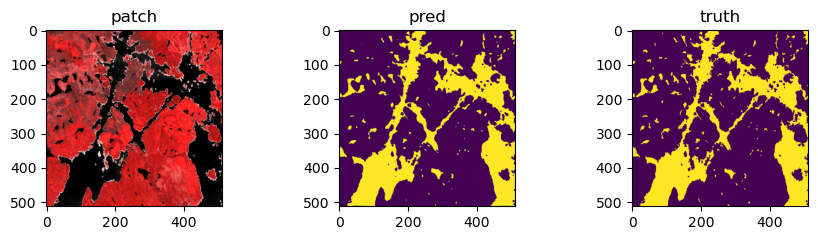

Ep160: tra-> Loss:0.074,Oa:0.972,Miou:0.864,                                 time:3.5s
Ep161: tra-> Loss:0.069,Oa:0.973,Miou:0.877,                                 time:3.6s
Ep162: tra-> Loss:0.069,Oa:0.974,Miou:0.882,                                 time:3.5s
Ep163: tra-> Loss:0.064,Oa:0.976,Miou:0.878,                                 time:3.5s
Ep164: tra-> Loss:0.062,Oa:0.978,Miou:0.893,                                 time:3.6s
Ep165: tra-> Loss:0.062,Oa:0.977,Miou:0.889,                                 time:3.6s
Ep166: tra-> Loss:0.067,Oa:0.975,Miou:0.887,                                 time:3.6s
Ep167: tra-> Loss:0.066,Oa:0.975,Miou:0.889,                                 time:3.4s
Ep168: tra-> Loss:0.069,Oa:0.976,Miou:0.899,                                 time:3.6s
Ep169: tra-> Loss:0.065,Oa:0.976,Miou:0.887,                                 time:3.4s
Ep170: tra-> Loss:0.071,Oa:0.975,Miou:0.891,                                 time:3.5s
Ep171: tra-> Loss:0.063,Oa:0.976,Miou:0.898

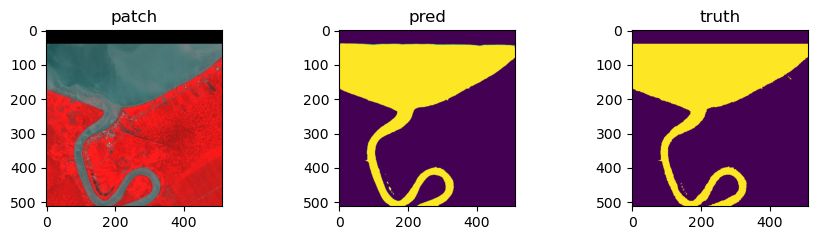

Ep180: tra-> Loss:0.062,Oa:0.977,Miou:0.900,                                 time:3.5s
Ep181: tra-> Loss:0.065,Oa:0.977,Miou:0.896,                                 time:3.5s
Ep182: tra-> Loss:0.067,Oa:0.974,Miou:0.874,                                 time:3.5s
Ep183: tra-> Loss:0.064,Oa:0.975,Miou:0.887,                                 time:3.6s
Ep184: tra-> Loss:0.065,Oa:0.976,Miou:0.879,                                 time:3.6s
Ep185: tra-> Loss:0.065,Oa:0.977,Miou:0.896,                                 time:3.5s
Ep186: tra-> Loss:0.066,Oa:0.976,Miou:0.892,                                 time:3.7s
Ep187: tra-> Loss:0.056,Oa:0.980,Miou:0.905,                                 time:3.5s
Ep188: tra-> Loss:0.057,Oa:0.979,Miou:0.893,                                 time:3.6s
Ep189: tra-> Loss:0.066,Oa:0.976,Miou:0.888,                                 time:3.5s
Ep190: tra-> Loss:0.070,Oa:0.976,Miou:0.891,                                 time:3.5s
Ep191: tra-> Loss:0.067,Oa:0.975,Miou:0.885

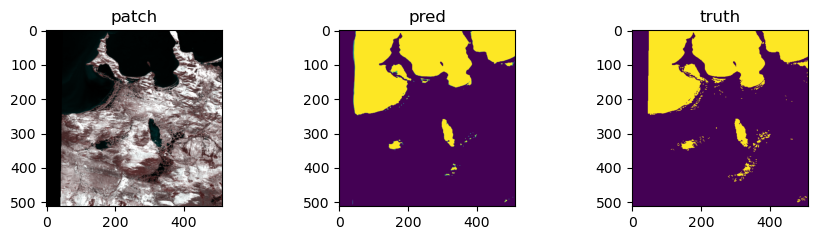

Ep200: tra-> Loss:0.079,Oa:0.971,Miou:0.861,                                 time:3.5s
Ep201: tra-> Loss:0.065,Oa:0.977,Miou:0.899,                                 time:3.5s
Ep202: tra-> Loss:0.054,Oa:0.980,Miou:0.903,                                 time:3.5s
Ep203: tra-> Loss:0.070,Oa:0.974,Miou:0.877,                                 time:3.6s
Ep204: tra-> Loss:0.066,Oa:0.975,Miou:0.873,                                 time:3.6s
Ep205: tra-> Loss:0.064,Oa:0.976,Miou:0.887,                                 time:3.6s
Ep206: tra-> Loss:0.060,Oa:0.978,Miou:0.892,                                 time:3.6s
Ep207: tra-> Loss:0.073,Oa:0.973,Miou:0.882,                                 time:3.5s
Ep208: tra-> Loss:0.061,Oa:0.977,Miou:0.895,                                 time:3.5s
Ep209: tra-> Loss:0.062,Oa:0.977,Miou:0.896,                                 time:3.5s
Ep210: tra-> Loss:0.065,Oa:0.977,Miou:0.896,                                 time:3.6s
Ep211: tra-> Loss:0.057,Oa:0.979,Miou:0.907

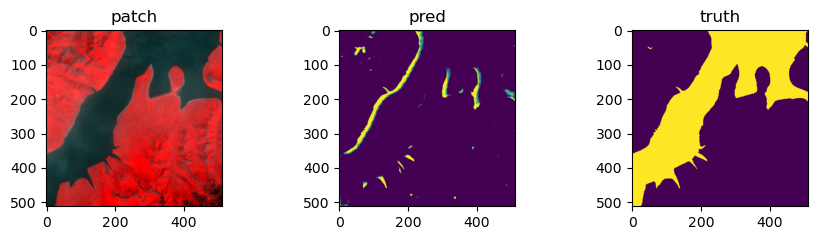

Ep220: tra-> Loss:0.060,Oa:0.978,Miou:0.907,                                 time:3.5s
Ep221: tra-> Loss:0.065,Oa:0.976,Miou:0.891,                                 time:3.5s
Ep222: tra-> Loss:0.057,Oa:0.978,Miou:0.901,                                 time:3.5s
Ep223: tra-> Loss:0.057,Oa:0.979,Miou:0.897,                                 time:3.7s
Ep224: tra-> Loss:0.053,Oa:0.981,Miou:0.906,                                 time:3.5s
Ep225: tra-> Loss:0.055,Oa:0.979,Miou:0.893,                                 time:3.6s
Ep226: tra-> Loss:0.053,Oa:0.981,Miou:0.903,                                 time:3.6s
Ep227: tra-> Loss:0.058,Oa:0.978,Miou:0.897,                                 time:3.5s
Ep228: tra-> Loss:0.062,Oa:0.975,Miou:0.895,                                 time:3.6s
Ep229: tra-> Loss:0.058,Oa:0.978,Miou:0.902,                                 time:3.5s
Ep230: tra-> Loss:0.059,Oa:0.978,Miou:0.895,                                 time:3.6s
Ep231: tra-> Loss:0.063,Oa:0.976,Miou:0.886

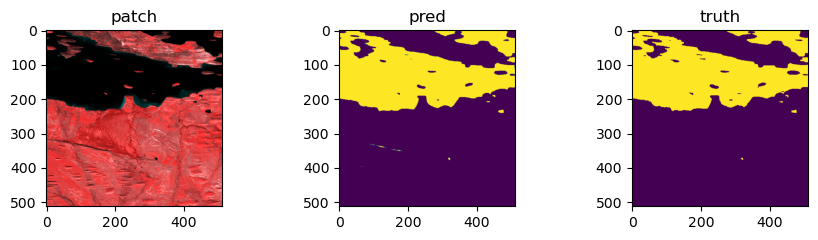

Ep240: tra-> Loss:0.062,Oa:0.977,Miou:0.897,                                 time:3.5s
Ep241: tra-> Loss:0.062,Oa:0.977,Miou:0.905,                                 time:3.5s
Ep242: tra-> Loss:0.060,Oa:0.977,Miou:0.891,                                 time:3.5s
Ep243: tra-> Loss:0.064,Oa:0.976,Miou:0.887,                                 time:3.5s
Ep244: tra-> Loss:0.059,Oa:0.978,Miou:0.898,                                 time:3.5s
Ep245: tra-> Loss:0.064,Oa:0.978,Miou:0.895,                                 time:3.6s
Ep246: tra-> Loss:0.084,Oa:0.970,Miou:0.859,                                 time:3.6s
Ep247: tra-> Loss:0.078,Oa:0.970,Miou:0.858,                                 time:3.6s
Ep248: tra-> Loss:0.069,Oa:0.974,Miou:0.888,                                 time:3.6s
Ep249: tra-> Loss:0.062,Oa:0.977,Miou:0.887,                                 time:3.5s
Ep250: tra-> Loss:0.069,Oa:0.976,Miou:0.896,                                 time:3.5s
Ep251: tra-> Loss:0.061,Oa:0.978,Miou:0.893

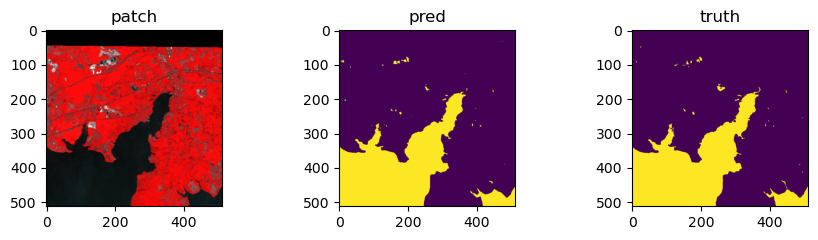

Ep260: tra-> Loss:0.058,Oa:0.977,Miou:0.897,                                 time:3.5s
Ep261: tra-> Loss:0.050,Oa:0.981,Miou:0.913,                                 time:3.6s
Ep262: tra-> Loss:0.064,Oa:0.976,Miou:0.892,                                 time:3.5s
Ep263: tra-> Loss:0.059,Oa:0.978,Miou:0.886,                                 time:3.5s
Ep264: tra-> Loss:0.058,Oa:0.980,Miou:0.907,                                 time:3.4s
Ep265: tra-> Loss:0.059,Oa:0.978,Miou:0.884,                                 time:3.6s
Ep266: tra-> Loss:0.066,Oa:0.977,Miou:0.882,                                 time:3.4s
Ep267: tra-> Loss:0.061,Oa:0.976,Miou:0.891,                                 time:3.6s
Ep268: tra-> Loss:0.062,Oa:0.977,Miou:0.897,                                 time:3.4s
Ep269: tra-> Loss:0.062,Oa:0.976,Miou:0.887,                                 time:3.4s
Ep270: tra-> Loss:0.059,Oa:0.978,Miou:0.898,                                 time:3.4s
Ep271: tra-> Loss:0.058,Oa:0.978,Miou:0.897

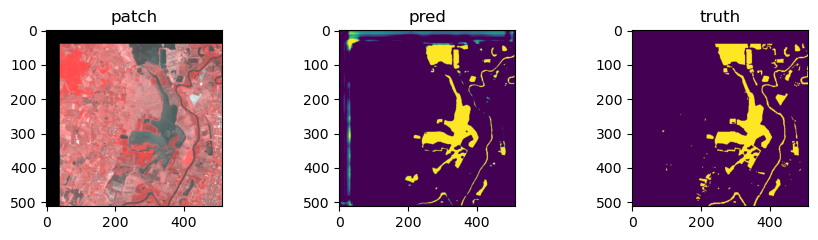

Ep280: tra-> Loss:0.075,Oa:0.973,Miou:0.880,                                 time:3.5s
Ep281: tra-> Loss:0.074,Oa:0.974,Miou:0.881,                                 time:3.6s
Ep282: tra-> Loss:0.058,Oa:0.978,Miou:0.897,                                 time:3.5s
Ep283: tra-> Loss:0.059,Oa:0.977,Miou:0.888,                                 time:3.4s
Ep284: tra-> Loss:0.073,Oa:0.973,Miou:0.874,                                 time:3.6s
Ep285: tra-> Loss:0.069,Oa:0.974,Miou:0.882,                                 time:3.5s
Ep286: tra-> Loss:0.071,Oa:0.974,Miou:0.882,                                 time:3.5s
Ep287: tra-> Loss:0.062,Oa:0.977,Miou:0.896,                                 time:3.5s
Ep288: tra-> Loss:0.065,Oa:0.975,Miou:0.869,                                 time:3.5s
Ep289: tra-> Loss:0.068,Oa:0.974,Miou:0.884,                                 time:3.4s
Ep290: tra-> Loss:0.063,Oa:0.977,Miou:0.891,                                 time:3.4s
Ep291: tra-> Loss:0.070,Oa:0.977,Miou:0.887

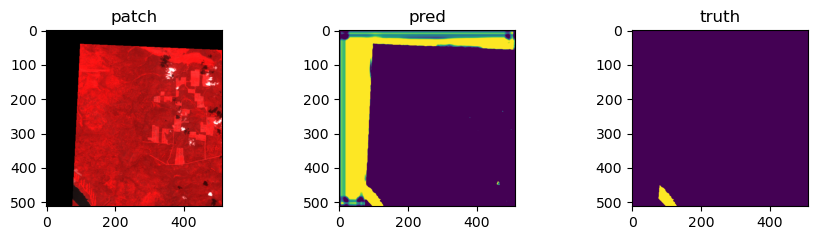

Ep300: tra-> Loss:0.062,Oa:0.977,Miou:0.893,                                 time:3.6s
Ep301: tra-> Loss:0.052,Oa:0.980,Miou:0.892,                                 time:3.5s
Ep302: tra-> Loss:0.061,Oa:0.979,Miou:0.904,                                 time:3.5s
Ep303: tra-> Loss:0.056,Oa:0.979,Miou:0.905,                                 time:3.5s
Ep304: tra-> Loss:0.053,Oa:0.981,Miou:0.902,                                 time:3.6s
Ep305: tra-> Loss:0.055,Oa:0.980,Miou:0.905,                                 time:3.5s
Ep306: tra-> Loss:0.057,Oa:0.979,Miou:0.901,                                 time:3.5s
Ep307: tra-> Loss:0.052,Oa:0.981,Miou:0.909,                                 time:3.6s
Ep308: tra-> Loss:0.056,Oa:0.979,Miou:0.901,                                 time:3.7s
Ep309: tra-> Loss:0.064,Oa:0.976,Miou:0.901,                                 time:3.4s
Ep310: tra-> Loss:0.064,Oa:0.976,Miou:0.895,                                 time:3.5s
Ep311: tra-> Loss:0.062,Oa:0.976,Miou:0.892

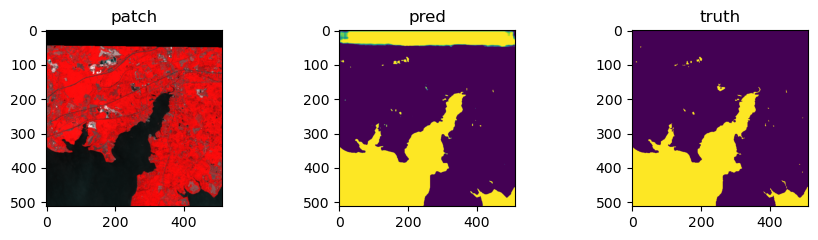

Ep320: tra-> Loss:0.053,Oa:0.980,Miou:0.912,                                 time:3.6s
Ep321: tra-> Loss:0.058,Oa:0.978,Miou:0.890,                                 time:3.5s
Ep322: tra-> Loss:0.058,Oa:0.979,Miou:0.900,                                 time:3.5s
Ep323: tra-> Loss:0.054,Oa:0.979,Miou:0.893,                                 time:3.5s
Ep324: tra-> Loss:0.060,Oa:0.978,Miou:0.902,                                 time:3.5s
Ep325: tra-> Loss:0.057,Oa:0.980,Miou:0.906,                                 time:3.5s
Ep326: tra-> Loss:0.053,Oa:0.980,Miou:0.911,                                 time:3.5s
Ep327: tra-> Loss:0.045,Oa:0.983,Miou:0.926,                                 time:3.4s
Ep328: tra-> Loss:0.051,Oa:0.981,Miou:0.912,                                 time:3.5s
Ep329: tra-> Loss:0.061,Oa:0.976,Miou:0.891,                                 time:3.5s
Ep330: tra-> Loss:0.056,Oa:0.980,Miou:0.908,                                 time:3.5s
Ep331: tra-> Loss:0.062,Oa:0.976,Miou:0.882

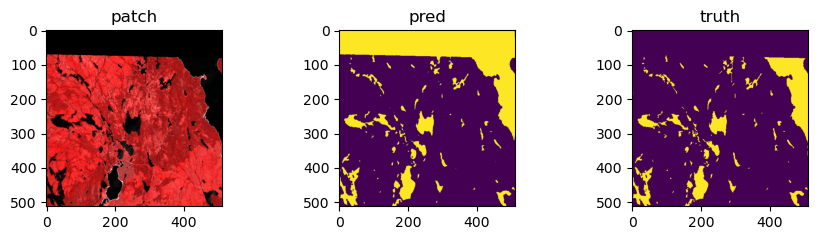

Ep340: tra-> Loss:0.059,Oa:0.978,Miou:0.892,                                 time:3.5s
Ep341: tra-> Loss:0.058,Oa:0.979,Miou:0.890,                                 time:3.6s
Ep342: tra-> Loss:0.059,Oa:0.978,Miou:0.890,                                 time:3.5s
Ep343: tra-> Loss:0.053,Oa:0.980,Miou:0.907,                                 time:3.6s
Ep344: tra-> Loss:0.063,Oa:0.977,Miou:0.888,                                 time:3.5s
Ep345: tra-> Loss:0.049,Oa:0.981,Miou:0.910,                                 time:3.4s
Ep346: tra-> Loss:0.049,Oa:0.981,Miou:0.914,                                 time:3.4s
Ep347: tra-> Loss:0.056,Oa:0.978,Miou:0.900,                                 time:3.7s
Ep348: tra-> Loss:0.061,Oa:0.977,Miou:0.900,                                 time:3.5s
Ep349: tra-> Loss:0.056,Oa:0.979,Miou:0.901,                                 time:3.5s
Ep350: tra-> Loss:0.059,Oa:0.979,Miou:0.907,                                 time:3.5s
Ep351: tra-> Loss:0.052,Oa:0.981,Miou:0.907

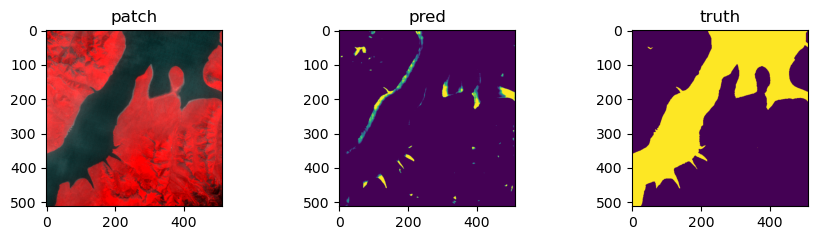

Ep360: tra-> Loss:0.062,Oa:0.976,Miou:0.882,                                 time:3.6s
Ep361: tra-> Loss:0.061,Oa:0.978,Miou:0.897,                                 time:3.6s
Ep362: tra-> Loss:0.060,Oa:0.977,Miou:0.891,                                 time:3.6s
Ep363: tra-> Loss:0.058,Oa:0.978,Miou:0.904,                                 time:3.5s
Ep364: tra-> Loss:0.059,Oa:0.978,Miou:0.907,                                 time:3.5s
Ep365: tra-> Loss:0.058,Oa:0.980,Miou:0.903,                                 time:3.7s
Ep366: tra-> Loss:0.061,Oa:0.979,Miou:0.910,                                 time:3.6s
Ep367: tra-> Loss:0.052,Oa:0.980,Miou:0.907,                                 time:3.5s
Ep368: tra-> Loss:0.054,Oa:0.980,Miou:0.904,                                 time:3.5s
Ep369: tra-> Loss:0.057,Oa:0.978,Miou:0.892,                                 time:3.6s
Ep370: tra-> Loss:0.058,Oa:0.978,Miou:0.889,                                 time:3.6s
Ep371: tra-> Loss:0.048,Oa:0.982,Miou:0.913

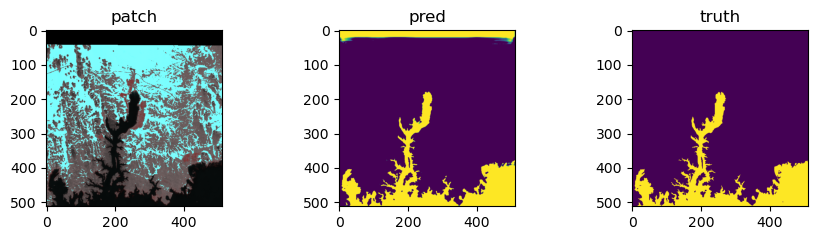

Ep380: tra-> Loss:0.067,Oa:0.977,Miou:0.887,                                 time:3.5s
Ep381: tra-> Loss:0.069,Oa:0.973,Miou:0.872,                                 time:3.4s
Ep382: tra-> Loss:0.065,Oa:0.974,Miou:0.885,                                 time:3.7s
Ep383: tra-> Loss:0.058,Oa:0.978,Miou:0.901,                                 time:3.5s
Ep384: tra-> Loss:0.049,Oa:0.982,Miou:0.912,                                 time:3.4s
Ep385: tra-> Loss:0.056,Oa:0.979,Miou:0.904,                                 time:3.5s
Ep386: tra-> Loss:0.052,Oa:0.980,Miou:0.905,                                 time:3.6s
Ep387: tra-> Loss:0.052,Oa:0.980,Miou:0.904,                                 time:3.4s
Ep388: tra-> Loss:0.053,Oa:0.980,Miou:0.909,                                 time:3.7s
Ep389: tra-> Loss:0.048,Oa:0.982,Miou:0.912,                                 time:3.4s
Ep390: tra-> Loss:0.064,Oa:0.981,Miou:0.910,                                 time:3.5s
Ep391: tra-> Loss:0.065,Oa:0.976,Miou:0.882

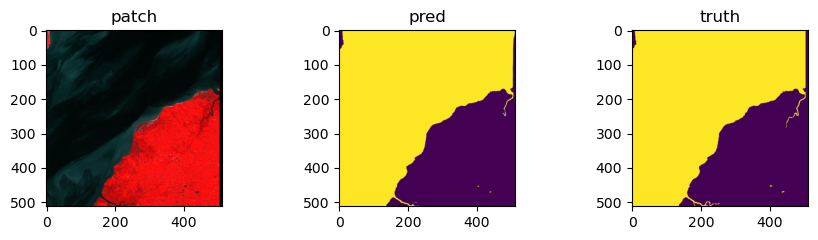

Ep400: tra-> Loss:0.066,Oa:0.977,Miou:0.890,                                 time:3.6s
Ep401: tra-> Loss:0.080,Oa:0.973,Miou:0.874,                                 time:3.6s
Ep402: tra-> Loss:0.056,Oa:0.979,Miou:0.906,                                 time:3.5s
Ep403: tra-> Loss:0.057,Oa:0.979,Miou:0.909,                                 time:3.4s
Ep404: tra-> Loss:0.057,Oa:0.979,Miou:0.907,                                 time:3.6s
Ep405: tra-> Loss:0.049,Oa:0.981,Miou:0.913,                                 time:3.5s
Ep406: tra-> Loss:0.063,Oa:0.977,Miou:0.887,                                 time:3.5s
Ep407: tra-> Loss:0.048,Oa:0.983,Miou:0.921,                                 time:3.6s
Ep408: tra-> Loss:0.053,Oa:0.981,Miou:0.903,                                 time:3.5s
Ep409: tra-> Loss:0.052,Oa:0.980,Miou:0.906,                                 time:3.5s
Ep410: tra-> Loss:0.056,Oa:0.980,Miou:0.901,                                 time:3.6s
Ep411: tra-> Loss:0.056,Oa:0.978,Miou:0.901

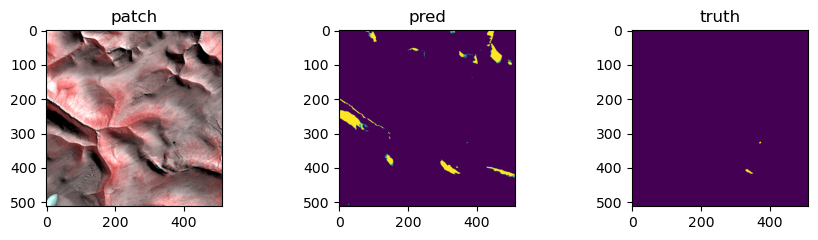

Ep420: tra-> Loss:0.059,Oa:0.978,Miou:0.896,                                 time:3.6s
Ep421: tra-> Loss:0.049,Oa:0.981,Miou:0.913,                                 time:3.5s
Ep422: tra-> Loss:0.052,Oa:0.980,Miou:0.910,                                 time:3.5s
Ep423: tra-> Loss:0.052,Oa:0.981,Miou:0.919,                                 time:3.6s
Ep424: tra-> Loss:0.044,Oa:0.983,Miou:0.919,                                 time:3.6s
Ep425: tra-> Loss:0.057,Oa:0.979,Miou:0.905,                                 time:3.6s
Ep426: tra-> Loss:0.059,Oa:0.978,Miou:0.897,                                 time:3.5s
Ep427: tra-> Loss:0.053,Oa:0.980,Miou:0.904,                                 time:3.4s
Ep428: tra-> Loss:0.055,Oa:0.980,Miou:0.913,                                 time:3.5s
Ep429: tra-> Loss:0.054,Oa:0.980,Miou:0.906,                                 time:3.6s
Ep430: tra-> Loss:0.055,Oa:0.979,Miou:0.912,                                 time:3.5s
Ep431: tra-> Loss:0.049,Oa:0.981,Miou:0.905

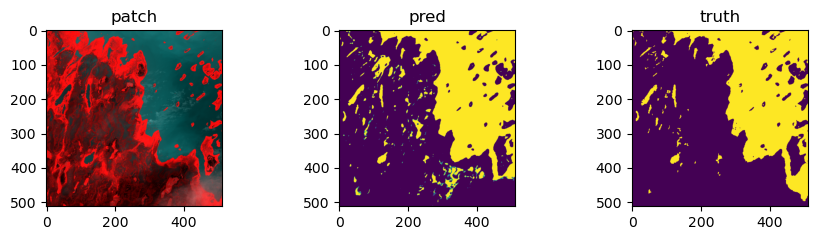

Ep440: tra-> Loss:0.053,Oa:0.980,Miou:0.915,                                 time:3.6s
Ep441: tra-> Loss:0.054,Oa:0.980,Miou:0.900,                                 time:3.7s
Ep442: tra-> Loss:0.055,Oa:0.979,Miou:0.900,                                 time:3.6s
Ep443: tra-> Loss:0.051,Oa:0.981,Miou:0.907,                                 time:3.6s
Ep444: tra-> Loss:0.053,Oa:0.980,Miou:0.906,                                 time:3.6s
Ep445: tra-> Loss:0.051,Oa:0.980,Miou:0.904,                                 time:3.6s
Ep446: tra-> Loss:0.050,Oa:0.980,Miou:0.906,                                 time:3.7s
Ep447: tra-> Loss:0.055,Oa:0.980,Miou:0.903,                                 time:3.6s
Ep448: tra-> Loss:0.056,Oa:0.981,Miou:0.908,                                 time:3.7s
Ep449: tra-> Loss:0.054,Oa:0.981,Miou:0.909,                                 time:3.7s
Ep450: tra-> Loss:0.057,Oa:0.978,Miou:0.893,                                 time:3.4s
Ep451: tra-> Loss:0.054,Oa:0.980,Miou:0.907

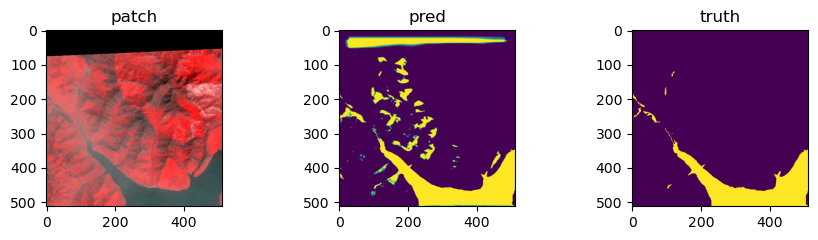

Ep460: tra-> Loss:0.060,Oa:0.977,Miou:0.899,                                 time:3.6s
Ep461: tra-> Loss:0.053,Oa:0.980,Miou:0.902,                                 time:3.6s
Ep462: tra-> Loss:0.053,Oa:0.980,Miou:0.906,                                 time:3.5s
Ep463: tra-> Loss:0.052,Oa:0.981,Miou:0.906,                                 time:3.5s
Ep464: tra-> Loss:0.054,Oa:0.980,Miou:0.902,                                 time:3.6s
Ep465: tra-> Loss:0.051,Oa:0.981,Miou:0.915,                                 time:3.7s
Ep466: tra-> Loss:0.043,Oa:0.983,Miou:0.922,                                 time:3.5s
Ep467: tra-> Loss:0.057,Oa:0.979,Miou:0.900,                                 time:3.5s
Ep468: tra-> Loss:0.053,Oa:0.980,Miou:0.905,                                 time:3.5s
Ep469: tra-> Loss:0.054,Oa:0.980,Miou:0.907,                                 time:3.5s
Ep470: tra-> Loss:0.046,Oa:0.983,Miou:0.918,                                 time:3.6s
Ep471: tra-> Loss:0.046,Oa:0.983,Miou:0.928

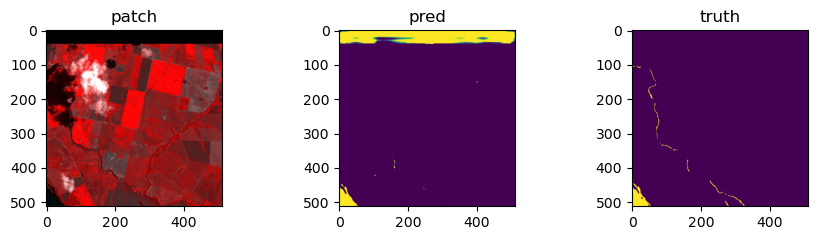

Ep480: tra-> Loss:0.049,Oa:0.981,Miou:0.909,                                 time:3.5s
Ep481: tra-> Loss:0.048,Oa:0.982,Miou:0.917,                                 time:3.6s
Ep482: tra-> Loss:0.056,Oa:0.979,Miou:0.899,                                 time:3.5s
Ep483: tra-> Loss:0.054,Oa:0.979,Miou:0.904,                                 time:3.5s
Ep484: tra-> Loss:0.057,Oa:0.979,Miou:0.908,                                 time:3.7s
Ep485: tra-> Loss:0.051,Oa:0.981,Miou:0.913,                                 time:3.5s
Ep486: tra-> Loss:0.048,Oa:0.982,Miou:0.910,                                 time:3.5s
Ep487: tra-> Loss:0.046,Oa:0.982,Miou:0.908,                                 time:3.6s
Ep488: tra-> Loss:0.050,Oa:0.981,Miou:0.913,                                 time:3.5s
Ep489: tra-> Loss:0.045,Oa:0.983,Miou:0.917,                                 time:3.6s
Ep490: tra-> Loss:0.047,Oa:0.983,Miou:0.914,                                 time:3.5s
Ep491: tra-> Loss:0.054,Oa:0.980,Miou:0.901

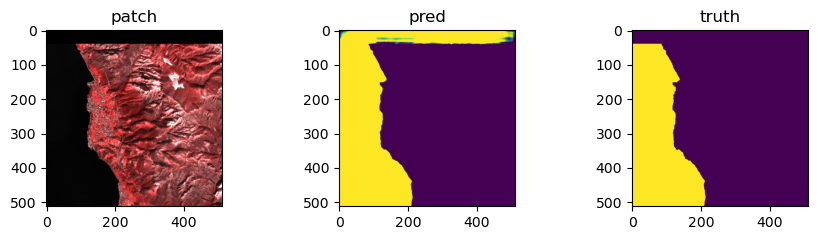

Ep500: tra-> Loss:0.051,Oa:0.981,Miou:0.913,                                 time:3.7s
Ep501: tra-> Loss:0.051,Oa:0.980,Miou:0.907, val-> Loss:0.1999,Oa:0.9066, Miou:0.6776,time:5.5s
Ep502: tra-> Loss:0.048,Oa:0.982,Miou:0.908,                                 time:3.6s
Ep503: tra-> Loss:0.073,Oa:0.978,Miou:0.907, val-> Loss:0.3644,Oa:0.8984, Miou:0.6565,time:5.6s
Ep504: tra-> Loss:0.061,Oa:0.978,Miou:0.887,                                 time:3.5s
Ep505: tra-> Loss:0.060,Oa:0.977,Miou:0.890, val-> Loss:0.3182,Oa:0.8991, Miou:0.6567,time:5.6s
Ep506: tra-> Loss:0.051,Oa:0.981,Miou:0.911,                                 time:3.6s
Ep507: tra-> Loss:0.049,Oa:0.981,Miou:0.902, val-> Loss:0.1639,Oa:0.9179, Miou:0.7012,time:5.7s
Ep508: tra-> Loss:0.056,Oa:0.979,Miou:0.909,                                 time:3.6s
Ep509: tra-> Loss:0.047,Oa:0.982,Miou:0.911, val-> Loss:0.1015,Oa:0.9603, Miou:0.8301,time:5.6s
Ep510: tra-> Loss:0.056,Oa:0.980,Miou:0.910,                                 time:3.5

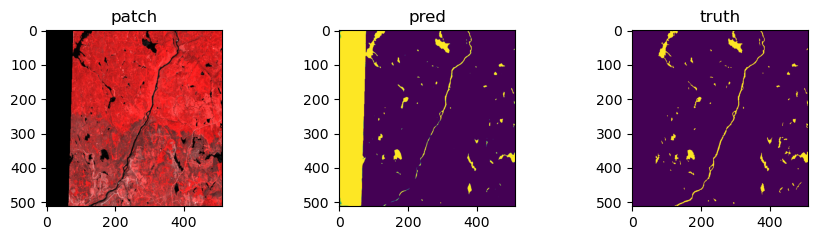

Ep520: tra-> Loss:0.055,Oa:0.980,Miou:0.907,                                 time:3.6s
Ep521: tra-> Loss:0.048,Oa:0.982,Miou:0.921, val-> Loss:0.1921,Oa:0.9037, Miou:0.6672,time:5.6s
Ep522: tra-> Loss:0.049,Oa:0.983,Miou:0.912,                                 time:3.5s
Ep523: tra-> Loss:0.050,Oa:0.981,Miou:0.911, val-> Loss:0.1300,Oa:0.9309, Miou:0.7387,time:5.7s
Ep524: tra-> Loss:0.083,Oa:0.974,Miou:0.884,                                 time:3.5s
Ep525: tra-> Loss:0.076,Oa:0.971,Miou:0.853, val-> Loss:0.0930,Oa:0.9710, Miou:0.8710,time:5.7s
Ep526: tra-> Loss:0.083,Oa:0.974,Miou:0.885,                                 time:3.6s
Ep527: tra-> Loss:0.093,Oa:0.968,Miou:0.854, val-> Loss:0.2691,Oa:0.8921, Miou:0.6460,time:5.7s
Ep528: tra-> Loss:0.063,Oa:0.978,Miou:0.889,                                 time:3.5s
Ep529: tra-> Loss:0.065,Oa:0.977,Miou:0.890, val-> Loss:0.0903,Oa:0.9647, Miou:0.8457,time:5.6s
Ep530: tra-> Loss:0.061,Oa:0.977,Miou:0.888,                                 time:3.6

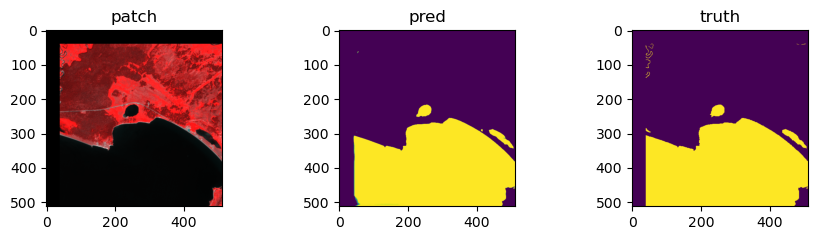

Ep540: tra-> Loss:0.058,Oa:0.978,Miou:0.894,                                 time:3.5s
Ep541: tra-> Loss:0.058,Oa:0.979,Miou:0.906, val-> Loss:0.1688,Oa:0.9066, Miou:0.6732,time:5.4s
Ep542: tra-> Loss:0.052,Oa:0.981,Miou:0.916,                                 time:3.4s
Ep543: tra-> Loss:0.053,Oa:0.980,Miou:0.906, val-> Loss:0.1432,Oa:0.9325, Miou:0.7420,time:5.5s
Ep544: tra-> Loss:0.055,Oa:0.980,Miou:0.909,                                 time:3.5s
Ep545: tra-> Loss:0.053,Oa:0.981,Miou:0.909, val-> Loss:0.2405,Oa:0.8970, Miou:0.6554,time:5.4s
Ep546: tra-> Loss:0.056,Oa:0.979,Miou:0.895,                                 time:3.4s
Ep547: tra-> Loss:0.052,Oa:0.981,Miou:0.897, val-> Loss:0.0746,Oa:0.9739, Miou:0.8816,time:5.4s
Ep548: tra-> Loss:0.051,Oa:0.981,Miou:0.908,                                 time:3.5s
Ep549: tra-> Loss:0.047,Oa:0.982,Miou:0.917, val-> Loss:0.0720,Oa:0.9745, Miou:0.8831,time:5.6s
Ep550: tra-> Loss:0.045,Oa:0.983,Miou:0.914,                                 time:3.5

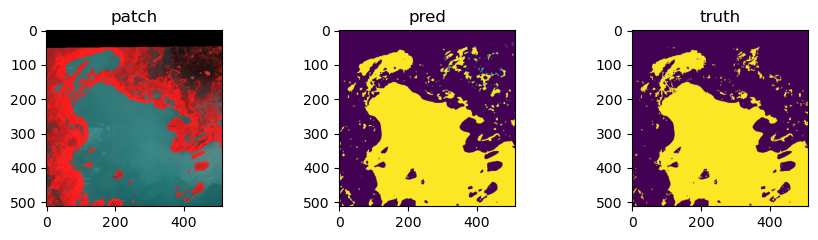

Ep560: tra-> Loss:0.051,Oa:0.981,Miou:0.908,                                 time:3.5s
Ep561: tra-> Loss:0.053,Oa:0.980,Miou:0.915, val-> Loss:0.4081,Oa:0.8967, Miou:0.6521,time:5.5s
Ep562: tra-> Loss:0.055,Oa:0.980,Miou:0.911,                                 time:3.5s
Ep563: tra-> Loss:0.048,Oa:0.982,Miou:0.914, val-> Loss:0.0730,Oa:0.9735, Miou:0.8792,time:5.5s
Ep564: tra-> Loss:0.054,Oa:0.980,Miou:0.905,                                 time:3.5s
Ep565: tra-> Loss:0.046,Oa:0.983,Miou:0.923, val-> Loss:0.0770,Oa:0.9734, Miou:0.8812,time:5.5s
Ep566: tra-> Loss:0.045,Oa:0.983,Miou:0.922,                                 time:3.5s
Ep567: tra-> Loss:0.052,Oa:0.980,Miou:0.908, val-> Loss:0.2244,Oa:0.9010, Miou:0.6594,time:5.4s
Ep568: tra-> Loss:0.047,Oa:0.982,Miou:0.918,                                 time:3.5s
Ep569: tra-> Loss:0.048,Oa:0.982,Miou:0.920, val-> Loss:0.1659,Oa:0.9152, Miou:0.6985,time:5.4s
Ep570: tra-> Loss:0.058,Oa:0.978,Miou:0.901,                                 time:3.5

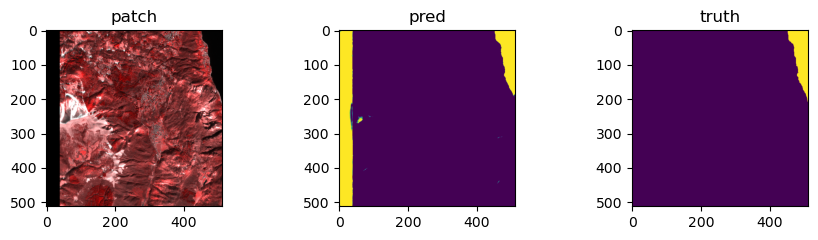

Ep580: tra-> Loss:0.048,Oa:0.982,Miou:0.917,                                 time:3.5s
Ep581: tra-> Loss:0.052,Oa:0.981,Miou:0.912, val-> Loss:0.2547,Oa:0.8993, Miou:0.6582,time:5.5s
Ep582: tra-> Loss:0.051,Oa:0.981,Miou:0.905,                                 time:3.6s
Ep583: tra-> Loss:0.047,Oa:0.982,Miou:0.920, val-> Loss:0.0701,Oa:0.9752, Miou:0.8853,time:5.5s
Ep584: tra-> Loss:0.052,Oa:0.980,Miou:0.903,                                 time:3.6s
Ep585: tra-> Loss:0.053,Oa:0.980,Miou:0.915, val-> Loss:0.1380,Oa:0.9247, Miou:0.7225,time:5.5s
Ep586: tra-> Loss:0.043,Oa:0.983,Miou:0.924,                                 time:3.4s
Ep587: tra-> Loss:0.045,Oa:0.983,Miou:0.914, val-> Loss:0.1756,Oa:0.9102, Miou:0.6835,time:5.5s
Ep588: tra-> Loss:0.045,Oa:0.984,Miou:0.923,                                 time:3.5s
Ep589: tra-> Loss:0.051,Oa:0.981,Miou:0.908, val-> Loss:0.2936,Oa:0.9032, Miou:0.6659,time:5.4s
Ep590: tra-> Loss:0.047,Oa:0.982,Miou:0.905,                                 time:3.5

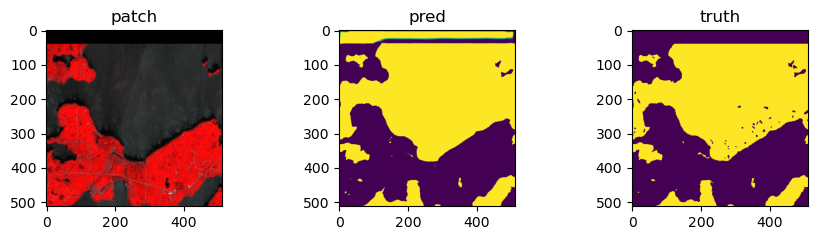

Ep600: tra-> Loss:0.049,Oa:0.982,Miou:0.908,                                 time:3.6s
Ep601: tra-> Loss:0.046,Oa:0.983,Miou:0.921, val-> Loss:0.3564,Oa:0.8956, Miou:0.6538,time:5.5s
Ep602: tra-> Loss:0.053,Oa:0.981,Miou:0.912,                                 time:3.5s
Ep603: tra-> Loss:0.044,Oa:0.983,Miou:0.914, val-> Loss:0.4593,Oa:0.8968, Miou:0.6540,time:5.4s
Ep604: tra-> Loss:0.050,Oa:0.982,Miou:0.919,                                 time:3.5s
Ep605: tra-> Loss:0.052,Oa:0.981,Miou:0.900, val-> Loss:0.2303,Oa:0.8993, Miou:0.6483,time:5.5s
Ep606: tra-> Loss:0.049,Oa:0.981,Miou:0.913,                                 time:3.4s
Ep607: tra-> Loss:0.049,Oa:0.981,Miou:0.909, val-> Loss:0.1578,Oa:0.9189, Miou:0.7061,time:5.5s
Ep608: tra-> Loss:0.050,Oa:0.980,Miou:0.905,                                 time:3.6s
Ep609: tra-> Loss:0.053,Oa:0.979,Miou:0.910, val-> Loss:0.3049,Oa:0.8963, Miou:0.6443,time:5.4s
Ep610: tra-> Loss:0.048,Oa:0.982,Miou:0.911,                                 time:3.5

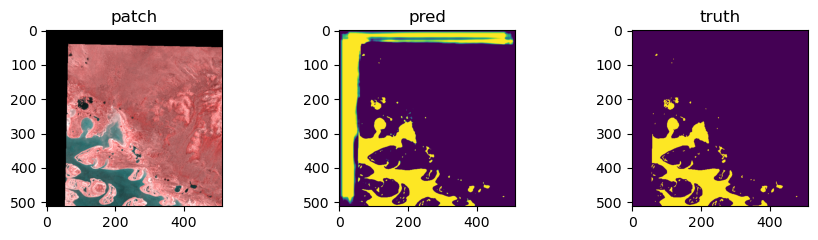

Ep620: tra-> Loss:0.046,Oa:0.983,Miou:0.919,                                 time:3.4s
Ep621: tra-> Loss:0.043,Oa:0.984,Miou:0.922, val-> Loss:0.1629,Oa:0.9120, Miou:0.6881,time:5.5s
Ep622: tra-> Loss:0.050,Oa:0.981,Miou:0.913,                                 time:3.5s
Ep623: tra-> Loss:0.043,Oa:0.983,Miou:0.915, val-> Loss:0.0715,Oa:0.9753, Miou:0.8864,time:5.4s
Ep624: tra-> Loss:0.052,Oa:0.981,Miou:0.905,                                 time:3.5s
Ep625: tra-> Loss:0.049,Oa:0.982,Miou:0.914, val-> Loss:0.1760,Oa:0.9044, Miou:0.6692,time:5.5s
Ep626: tra-> Loss:0.058,Oa:0.980,Miou:0.909,                                 time:3.5s
Ep627: tra-> Loss:0.050,Oa:0.981,Miou:0.906, val-> Loss:0.1143,Oa:0.9576, Miou:0.8209,time:5.5s
Ep628: tra-> Loss:0.050,Oa:0.981,Miou:0.900,                                 time:3.6s
Ep629: tra-> Loss:0.044,Oa:0.983,Miou:0.918, val-> Loss:0.2242,Oa:0.9023, Miou:0.6642,time:5.4s
Ep630: tra-> Loss:0.046,Oa:0.983,Miou:0.924,                                 time:3.5

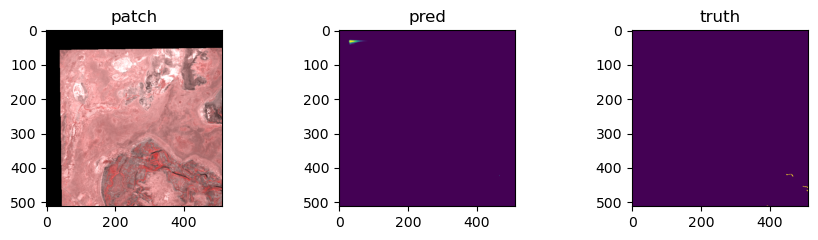

Ep640: tra-> Loss:0.046,Oa:0.982,Miou:0.920,                                 time:3.5s
Ep641: tra-> Loss:0.045,Oa:0.983,Miou:0.923, val-> Loss:0.3435,Oa:0.8966, Miou:0.6536,time:5.5s
Ep642: tra-> Loss:0.047,Oa:0.983,Miou:0.917,                                 time:3.6s
Ep643: tra-> Loss:0.045,Oa:0.984,Miou:0.917, val-> Loss:0.0831,Oa:0.9709, Miou:0.8687,time:5.5s
Ep644: tra-> Loss:0.043,Oa:0.983,Miou:0.916,                                 time:3.4s
Ep645: tra-> Loss:0.046,Oa:0.982,Miou:0.910, val-> Loss:0.2803,Oa:0.9004, Miou:0.6629,time:5.4s
Ep646: tra-> Loss:0.043,Oa:0.983,Miou:0.924,                                 time:3.5s
Ep647: tra-> Loss:0.043,Oa:0.984,Miou:0.924, val-> Loss:0.2887,Oa:0.8990, Miou:0.6583,time:5.5s
Ep648: tra-> Loss:0.043,Oa:0.984,Miou:0.927,                                 time:3.4s
Ep649: tra-> Loss:0.045,Oa:0.983,Miou:0.915, val-> Loss:0.0882,Oa:0.9717, Miou:0.8731,time:5.4s
Ep650: tra-> Loss:0.048,Oa:0.982,Miou:0.916,                                 time:3.5

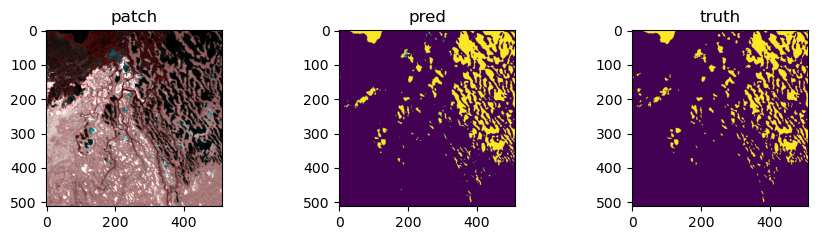

Ep660: tra-> Loss:0.051,Oa:0.982,Miou:0.914,                                 time:3.6s
Ep661: tra-> Loss:0.050,Oa:0.983,Miou:0.906, val-> Loss:0.2535,Oa:0.8985, Miou:0.6559,time:5.5s
Ep662: tra-> Loss:0.053,Oa:0.981,Miou:0.916,                                 time:3.6s
Ep663: tra-> Loss:0.043,Oa:0.984,Miou:0.928, val-> Loss:0.2096,Oa:0.9028, Miou:0.6679,time:5.6s
Ep664: tra-> Loss:0.049,Oa:0.981,Miou:0.906,                                 time:3.6s
Ep665: tra-> Loss:0.048,Oa:0.982,Miou:0.914, val-> Loss:0.2749,Oa:0.8997, Miou:0.6592,time:5.6s
Ep666: tra-> Loss:0.050,Oa:0.981,Miou:0.913,                                 time:3.5s
Ep667: tra-> Loss:0.053,Oa:0.980,Miou:0.896, val-> Loss:0.3246,Oa:0.8958, Miou:0.6511,time:5.5s
Ep668: tra-> Loss:0.048,Oa:0.982,Miou:0.910,                                 time:3.4s
Ep669: tra-> Loss:0.052,Oa:0.981,Miou:0.906, val-> Loss:0.3301,Oa:0.8971, Miou:0.6551,time:5.5s
Ep670: tra-> Loss:0.052,Oa:0.981,Miou:0.907,                                 time:3.3

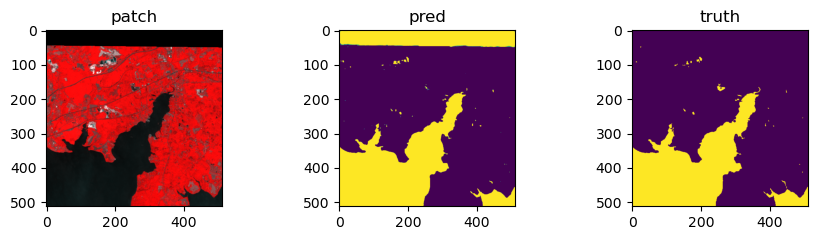

Ep680: tra-> Loss:0.049,Oa:0.981,Miou:0.906,                                 time:3.6s
Ep681: tra-> Loss:0.045,Oa:0.983,Miou:0.920, val-> Loss:0.0682,Oa:0.9774, Miou:0.8960,time:5.5s
Ep682: tra-> Loss:0.045,Oa:0.983,Miou:0.920,                                 time:3.4s
Ep683: tra-> Loss:0.055,Oa:0.978,Miou:0.897, val-> Loss:0.1553,Oa:0.9524, Miou:0.7937,time:5.6s
Ep684: tra-> Loss:0.055,Oa:0.980,Miou:0.896,                                 time:3.5s
Ep685: tra-> Loss:0.050,Oa:0.981,Miou:0.916, val-> Loss:0.3570,Oa:0.8966, Miou:0.6530,time:5.4s
Ep686: tra-> Loss:0.042,Oa:0.984,Miou:0.923,                                 time:3.4s
Ep687: tra-> Loss:0.045,Oa:0.983,Miou:0.921, val-> Loss:0.1779,Oa:0.9117, Miou:0.6878,time:5.5s
Ep688: tra-> Loss:0.047,Oa:0.983,Miou:0.913,                                 time:3.6s
Ep689: tra-> Loss:0.046,Oa:0.983,Miou:0.923, val-> Loss:0.2234,Oa:0.9014, Miou:0.6652,time:5.5s
Ep690: tra-> Loss:0.043,Oa:0.985,Miou:0.928,                                 time:3.5

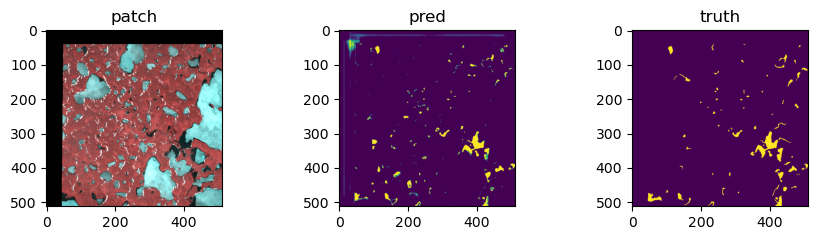

Ep700: tra-> Loss:0.061,Oa:0.977,Miou:0.896,                                 time:3.5s
Ep701: tra-> Loss:0.047,Oa:0.983,Miou:0.925, val-> Loss:0.2506,Oa:0.9085, Miou:0.6824,time:5.5s
Ep702: tra-> Loss:0.046,Oa:0.983,Miou:0.918,                                 time:3.5s
Ep703: tra-> Loss:0.042,Oa:0.984,Miou:0.925, val-> Loss:0.0671,Oa:0.9751, Miou:0.8869,time:5.6s
Ep704: tra-> Loss:0.040,Oa:0.985,Miou:0.923,                                 time:3.4s
Ep705: tra-> Loss:0.042,Oa:0.985,Miou:0.928, val-> Loss:0.3099,Oa:0.9016, Miou:0.6662,time:5.5s
Ep706: tra-> Loss:0.047,Oa:0.983,Miou:0.924,                                 time:3.5s
Ep707: tra-> Loss:0.044,Oa:0.983,Miou:0.917, val-> Loss:0.3397,Oa:0.8995, Miou:0.6609,time:5.4s
Ep708: tra-> Loss:0.046,Oa:0.984,Miou:0.916,                                 time:3.6s
Ep709: tra-> Loss:0.046,Oa:0.983,Miou:0.921, val-> Loss:0.4552,Oa:0.8970, Miou:0.6546,time:5.5s
Ep710: tra-> Loss:0.047,Oa:0.983,Miou:0.920,                                 time:3.5

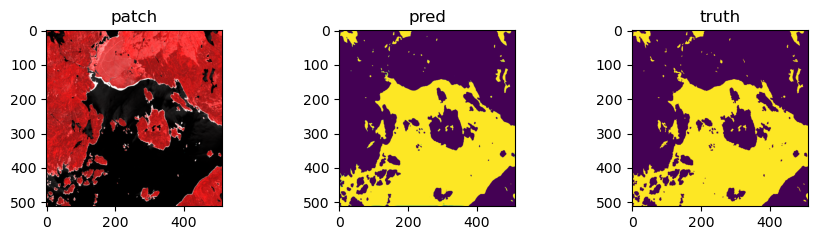

Ep720: tra-> Loss:0.051,Oa:0.980,Miou:0.910,                                 time:3.5s
Ep721: tra-> Loss:0.048,Oa:0.982,Miou:0.915, val-> Loss:0.1875,Oa:0.9111, Miou:0.6901,time:5.5s
Ep722: tra-> Loss:0.046,Oa:0.983,Miou:0.919,                                 time:3.6s
Ep723: tra-> Loss:0.049,Oa:0.982,Miou:0.918, val-> Loss:0.3199,Oa:0.8974, Miou:0.6587,time:5.6s
Ep724: tra-> Loss:0.042,Oa:0.984,Miou:0.924,                                 time:3.5s
Ep725: tra-> Loss:0.048,Oa:0.983,Miou:0.920, val-> Loss:0.1860,Oa:0.9106, Miou:0.6849,time:5.6s
Ep726: tra-> Loss:0.047,Oa:0.982,Miou:0.913,                                 time:3.5s
Ep727: tra-> Loss:0.045,Oa:0.983,Miou:0.922, val-> Loss:0.1925,Oa:0.9042, Miou:0.6705,time:5.6s
Ep728: tra-> Loss:0.043,Oa:0.984,Miou:0.925,                                 time:3.5s
Ep729: tra-> Loss:0.052,Oa:0.981,Miou:0.909, val-> Loss:0.3658,Oa:0.8984, Miou:0.6594,time:5.5s
Ep730: tra-> Loss:0.044,Oa:0.983,Miou:0.914,                                 time:3.6

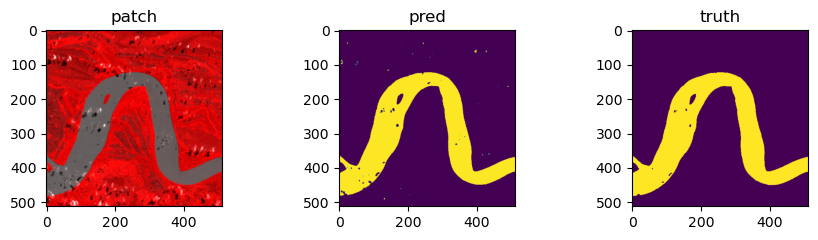

Ep740: tra-> Loss:0.049,Oa:0.982,Miou:0.920,                                 time:3.5s
Ep741: tra-> Loss:0.045,Oa:0.983,Miou:0.921, val-> Loss:0.2128,Oa:0.9029, Miou:0.6669,time:5.5s
Ep742: tra-> Loss:0.048,Oa:0.982,Miou:0.912,                                 time:3.4s
Ep743: tra-> Loss:0.051,Oa:0.981,Miou:0.916, val-> Loss:0.4709,Oa:0.8939, Miou:0.6512,time:5.5s
Ep744: tra-> Loss:0.054,Oa:0.980,Miou:0.907,                                 time:3.5s
Ep745: tra-> Loss:0.053,Oa:0.980,Miou:0.907, val-> Loss:0.1399,Oa:0.9237, Miou:0.7191,time:5.7s
Ep746: tra-> Loss:0.051,Oa:0.982,Miou:0.912,                                 time:3.5s
Ep747: tra-> Loss:0.047,Oa:0.983,Miou:0.916, val-> Loss:0.2000,Oa:0.9092, Miou:0.6835,time:5.6s
Ep748: tra-> Loss:0.044,Oa:0.984,Miou:0.925,                                 time:3.5s
Ep749: tra-> Loss:0.048,Oa:0.982,Miou:0.909, val-> Loss:0.1661,Oa:0.9121, Miou:0.6902,time:5.5s
Ep750: tra-> Loss:0.046,Oa:0.982,Miou:0.914,                                 time:3.4

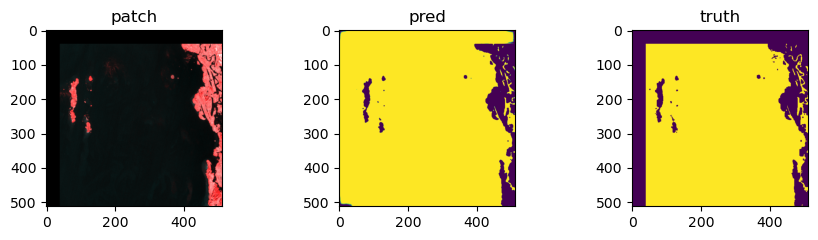

Ep760: tra-> Loss:0.049,Oa:0.982,Miou:0.910,                                 time:3.5s
Ep761: tra-> Loss:0.043,Oa:0.984,Miou:0.924, val-> Loss:0.1364,Oa:0.9300, Miou:0.7357,time:5.6s
Ep762: tra-> Loss:0.051,Oa:0.982,Miou:0.910,                                 time:3.5s
Ep763: tra-> Loss:0.047,Oa:0.981,Miou:0.909, val-> Loss:0.1945,Oa:0.9040, Miou:0.6705,time:5.6s
Ep764: tra-> Loss:0.046,Oa:0.983,Miou:0.914,                                 time:3.7s
Ep765: tra-> Loss:0.048,Oa:0.982,Miou:0.913, val-> Loss:0.3828,Oa:0.8964, Miou:0.6554,time:5.7s
Ep766: tra-> Loss:0.042,Oa:0.984,Miou:0.923,                                 time:3.5s
Ep767: tra-> Loss:0.049,Oa:0.982,Miou:0.911, val-> Loss:0.2991,Oa:0.8973, Miou:0.6558,time:5.7s
Ep768: tra-> Loss:0.043,Oa:0.985,Miou:0.918,                                 time:3.5s
Ep769: tra-> Loss:0.054,Oa:0.979,Miou:0.895, val-> Loss:0.2005,Oa:0.9044, Miou:0.6722,time:5.8s
Ep770: tra-> Loss:0.048,Oa:0.982,Miou:0.907,                                 time:3.6

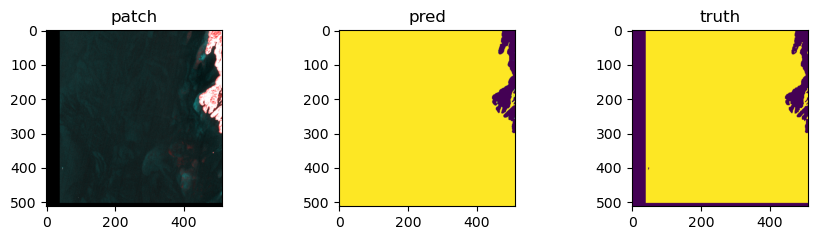

Ep780: tra-> Loss:0.042,Oa:0.984,Miou:0.923,                                 time:3.6s
Ep781: tra-> Loss:0.044,Oa:0.983,Miou:0.919, val-> Loss:0.1382,Oa:0.9224, Miou:0.7079,time:5.6s
Ep782: tra-> Loss:0.047,Oa:0.983,Miou:0.908,                                 time:3.5s
Ep783: tra-> Loss:0.045,Oa:0.983,Miou:0.914, val-> Loss:0.1179,Oa:0.9489, Miou:0.7897,time:5.7s
Ep784: tra-> Loss:0.045,Oa:0.983,Miou:0.920,                                 time:3.5s
Ep785: tra-> Loss:0.052,Oa:0.981,Miou:0.912, val-> Loss:0.0642,Oa:0.9765, Miou:0.8920,time:5.6s
Ep786: tra-> Loss:0.050,Oa:0.982,Miou:0.907,                                 time:3.5s
Ep787: tra-> Loss:0.048,Oa:0.982,Miou:0.917, val-> Loss:0.0871,Oa:0.9691, Miou:0.8613,time:5.6s
Ep788: tra-> Loss:0.042,Oa:0.984,Miou:0.920,                                 time:3.6s
Ep789: tra-> Loss:0.045,Oa:0.984,Miou:0.927, val-> Loss:0.2138,Oa:0.9067, Miou:0.6757,time:5.7s
Ep790: tra-> Loss:0.042,Oa:0.984,Miou:0.925,                                 time:3.6

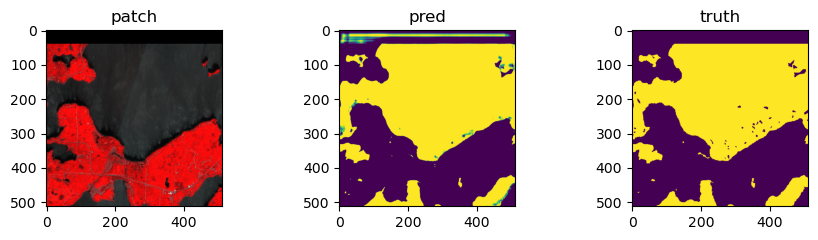

Ep800: tra-> Loss:0.046,Oa:0.983,Miou:0.915,                                 time:3.6s
Ep801: tra-> Loss:0.053,Oa:0.981,Miou:0.910, val-> Loss:0.2707,Oa:0.8973, Miou:0.6545,time:5.6s
Ep802: tra-> Loss:0.049,Oa:0.982,Miou:0.910,                                 time:3.5s
Ep803: tra-> Loss:0.042,Oa:0.984,Miou:0.924, val-> Loss:0.2880,Oa:0.9003, Miou:0.6597,time:5.6s
Ep804: tra-> Loss:0.049,Oa:0.981,Miou:0.911,                                 time:3.5s
Ep805: tra-> Loss:0.052,Oa:0.980,Miou:0.905, val-> Loss:0.2800,Oa:0.9018, Miou:0.6660,time:5.5s
Ep806: tra-> Loss:0.046,Oa:0.984,Miou:0.923,                                 time:3.5s
Ep807: tra-> Loss:0.043,Oa:0.983,Miou:0.921, val-> Loss:0.1407,Oa:0.9295, Miou:0.7358,time:5.6s
Ep808: tra-> Loss:0.048,Oa:0.981,Miou:0.914,                                 time:3.6s
Ep809: tra-> Loss:0.045,Oa:0.983,Miou:0.921, val-> Loss:0.1678,Oa:0.9154, Miou:0.6977,time:5.7s
Ep810: tra-> Loss:0.048,Oa:0.982,Miou:0.910,                                 time:3.6

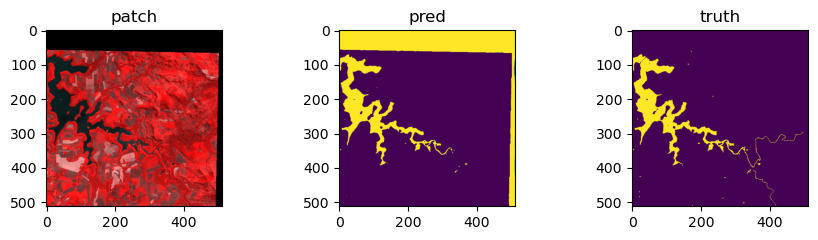

Ep820: tra-> Loss:0.040,Oa:0.985,Miou:0.930,                                 time:3.5s
Ep821: tra-> Loss:0.048,Oa:0.982,Miou:0.903, val-> Loss:0.1718,Oa:0.9120, Miou:0.6877,time:5.6s
Ep822: tra-> Loss:0.049,Oa:0.982,Miou:0.908,                                 time:3.6s
Ep823: tra-> Loss:0.045,Oa:0.984,Miou:0.921, val-> Loss:0.2368,Oa:0.9041, Miou:0.6672,time:5.5s
Ep824: tra-> Loss:0.045,Oa:0.983,Miou:0.924,                                 time:3.5s
Ep825: tra-> Loss:0.046,Oa:0.983,Miou:0.919, val-> Loss:0.3597,Oa:0.8982, Miou:0.6595,time:5.5s
Ep826: tra-> Loss:0.055,Oa:0.980,Miou:0.911,                                 time:3.5s
Ep827: tra-> Loss:0.043,Oa:0.984,Miou:0.924, val-> Loss:0.1672,Oa:0.9185, Miou:0.7068,time:5.5s
Ep828: tra-> Loss:0.045,Oa:0.983,Miou:0.922,                                 time:3.5s
Ep829: tra-> Loss:0.041,Oa:0.984,Miou:0.919, val-> Loss:0.4577,Oa:0.8997, Miou:0.6602,time:5.5s
Ep830: tra-> Loss:0.043,Oa:0.984,Miou:0.921,                                 time:3.4

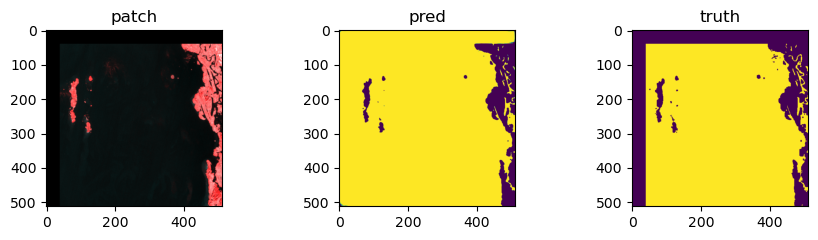

Ep840: tra-> Loss:0.049,Oa:0.982,Miou:0.917,                                 time:3.6s
Ep841: tra-> Loss:0.046,Oa:0.982,Miou:0.917, val-> Loss:0.1548,Oa:0.9251, Miou:0.7223,time:5.5s
Ep842: tra-> Loss:0.043,Oa:0.984,Miou:0.926,                                 time:3.4s
Ep843: tra-> Loss:0.042,Oa:0.984,Miou:0.925, val-> Loss:0.1377,Oa:0.9287, Miou:0.7322,time:5.5s
Ep844: tra-> Loss:0.049,Oa:0.981,Miou:0.917,                                 time:3.6s
Ep845: tra-> Loss:0.045,Oa:0.983,Miou:0.916, val-> Loss:0.1563,Oa:0.9144, Miou:0.6976,time:5.6s
Ep846: tra-> Loss:0.039,Oa:0.985,Miou:0.928,                                 time:3.4s
Ep847: tra-> Loss:0.042,Oa:0.984,Miou:0.924, val-> Loss:0.4185,Oa:0.8981, Miou:0.6574,time:5.5s
Ep848: tra-> Loss:0.043,Oa:0.985,Miou:0.926,                                 time:3.5s
Ep849: tra-> Loss:0.049,Oa:0.982,Miou:0.908, val-> Loss:0.3055,Oa:0.8982, Miou:0.6562,time:5.6s
Ep850: tra-> Loss:0.051,Oa:0.981,Miou:0.920,                                 time:3.5

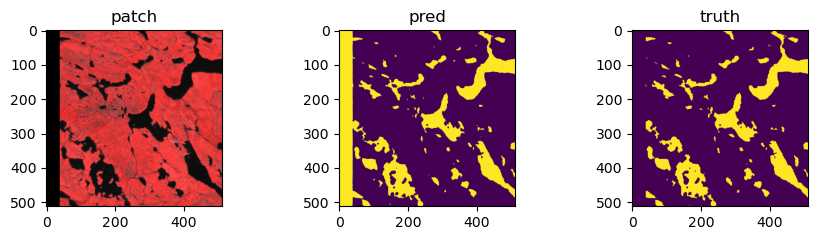

Ep860: tra-> Loss:0.044,Oa:0.983,Miou:0.914,                                 time:3.6s
Ep861: tra-> Loss:0.041,Oa:0.985,Miou:0.924, val-> Loss:0.1771,Oa:0.9100, Miou:0.6832,time:5.6s
Ep862: tra-> Loss:0.043,Oa:0.984,Miou:0.931,                                 time:3.5s
Ep863: tra-> Loss:0.047,Oa:0.982,Miou:0.913, val-> Loss:0.1375,Oa:0.9392, Miou:0.7617,time:5.4s
Ep864: tra-> Loss:0.045,Oa:0.983,Miou:0.921,                                 time:3.5s
Ep865: tra-> Loss:0.045,Oa:0.983,Miou:0.922, val-> Loss:0.2381,Oa:0.9018, Miou:0.6663,time:5.5s
Ep866: tra-> Loss:0.043,Oa:0.983,Miou:0.926,                                 time:3.5s
Ep867: tra-> Loss:0.045,Oa:0.983,Miou:0.921, val-> Loss:0.3965,Oa:0.9001, Miou:0.6628,time:5.5s
Ep868: tra-> Loss:0.043,Oa:0.983,Miou:0.925,                                 time:3.5s
Ep869: tra-> Loss:0.045,Oa:0.983,Miou:0.918, val-> Loss:0.3721,Oa:0.8989, Miou:0.6561,time:5.4s
Ep870: tra-> Loss:0.047,Oa:0.982,Miou:0.923,                                 time:3.4

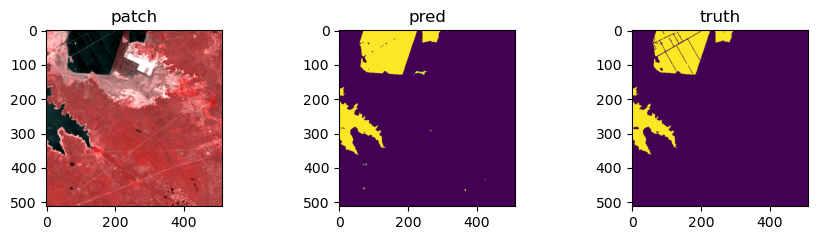

Ep880: tra-> Loss:0.041,Oa:0.985,Miou:0.920,                                 time:3.6s
Ep881: tra-> Loss:0.052,Oa:0.983,Miou:0.917, val-> Loss:0.1904,Oa:0.9130, Miou:0.6934,time:5.6s
Ep882: tra-> Loss:0.047,Oa:0.982,Miou:0.916,                                 time:3.4s
Ep883: tra-> Loss:0.048,Oa:0.982,Miou:0.909, val-> Loss:0.1719,Oa:0.9096, Miou:0.6845,time:5.6s
Ep884: tra-> Loss:0.047,Oa:0.983,Miou:0.917,                                 time:3.5s
Ep885: tra-> Loss:0.041,Oa:0.984,Miou:0.927, val-> Loss:0.3877,Oa:0.8984, Miou:0.6569,time:5.5s
Ep886: tra-> Loss:0.039,Oa:0.985,Miou:0.925,                                 time:3.4s
Ep887: tra-> Loss:0.051,Oa:0.982,Miou:0.911, val-> Loss:0.0935,Oa:0.9615, Miou:0.8346,time:5.5s
Ep888: tra-> Loss:0.045,Oa:0.983,Miou:0.921,                                 time:3.7s
Ep889: tra-> Loss:0.039,Oa:0.986,Miou:0.931, val-> Loss:0.2446,Oa:0.9030, Miou:0.6660,time:5.6s
Ep890: tra-> Loss:0.045,Oa:0.983,Miou:0.920,                                 time:3.5

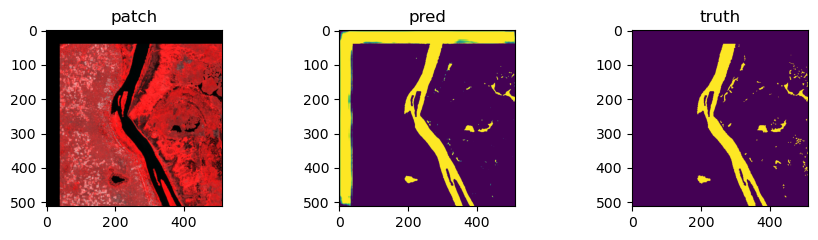

Ep900: tra-> Loss:0.054,Oa:0.982,Miou:0.908,                                 time:3.6s
Ep901: tra-> Loss:0.048,Oa:0.984,Miou:0.921, val-> Loss:0.0731,Oa:0.9755, Miou:0.8875,time:5.6s
Ep902: tra-> Loss:0.046,Oa:0.982,Miou:0.917,                                 time:3.5s
Ep903: tra-> Loss:0.043,Oa:0.983,Miou:0.922, val-> Loss:0.1823,Oa:0.9102, Miou:0.6848,time:5.7s
Ep904: tra-> Loss:0.049,Oa:0.981,Miou:0.913,                                 time:3.5s
Ep905: tra-> Loss:0.041,Oa:0.984,Miou:0.924, val-> Loss:0.1113,Oa:0.9499, Miou:0.7973,time:5.5s
Ep906: tra-> Loss:0.042,Oa:0.984,Miou:0.922,                                 time:3.6s
Ep907: tra-> Loss:0.044,Oa:0.983,Miou:0.923, val-> Loss:0.3470,Oa:0.8997, Miou:0.6613,time:5.5s
Ep908: tra-> Loss:0.042,Oa:0.984,Miou:0.926,                                 time:3.5s
Ep909: tra-> Loss:0.047,Oa:0.982,Miou:0.917, val-> Loss:0.2786,Oa:0.9010, Miou:0.6627,time:5.5s
Ep910: tra-> Loss:0.043,Oa:0.984,Miou:0.919,                                 time:3.5

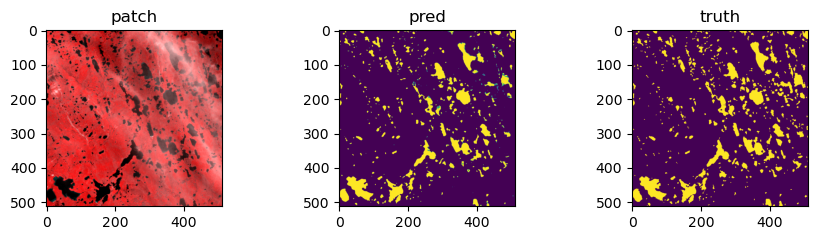

Ep920: tra-> Loss:0.038,Oa:0.985,Miou:0.927,                                 time:3.5s
Ep921: tra-> Loss:0.040,Oa:0.984,Miou:0.924, val-> Loss:0.2230,Oa:0.9018, Miou:0.6633,time:5.5s
Ep922: tra-> Loss:0.042,Oa:0.984,Miou:0.928,                                 time:3.5s
Ep923: tra-> Loss:0.042,Oa:0.985,Miou:0.925, val-> Loss:0.2103,Oa:0.9088, Miou:0.6778,time:5.6s
Ep924: tra-> Loss:0.041,Oa:0.986,Miou:0.925,                                 time:3.4s
Ep925: tra-> Loss:0.045,Oa:0.982,Miou:0.921, val-> Loss:0.4368,Oa:0.8974, Miou:0.6578,time:5.5s
Ep926: tra-> Loss:0.046,Oa:0.983,Miou:0.925,                                 time:3.6s
Ep927: tra-> Loss:0.044,Oa:0.984,Miou:0.920, val-> Loss:0.5227,Oa:0.8964, Miou:0.6515,time:5.5s
Ep928: tra-> Loss:0.048,Oa:0.982,Miou:0.918,                                 time:3.5s
Ep929: tra-> Loss:0.043,Oa:0.984,Miou:0.921, val-> Loss:0.2407,Oa:0.9027, Miou:0.6667,time:5.6s
Ep930: tra-> Loss:0.041,Oa:0.985,Miou:0.930,                                 time:3.5

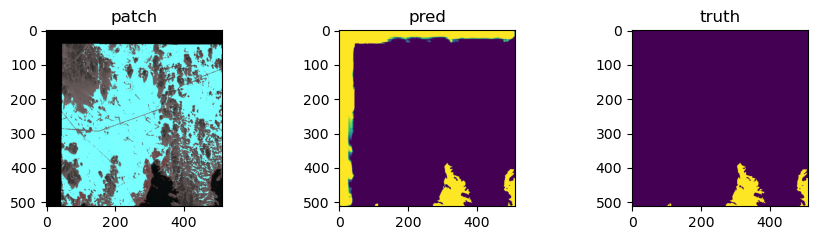

Ep940: tra-> Loss:0.048,Oa:0.982,Miou:0.915,                                 time:3.7s
Ep941: tra-> Loss:0.045,Oa:0.983,Miou:0.917, val-> Loss:0.3449,Oa:0.9001, Miou:0.6624,time:5.6s
Ep942: tra-> Loss:0.045,Oa:0.983,Miou:0.917,                                 time:3.5s
Ep943: tra-> Loss:0.045,Oa:0.983,Miou:0.920, val-> Loss:0.2586,Oa:0.9026, Miou:0.6674,time:5.6s
Ep944: tra-> Loss:0.040,Oa:0.985,Miou:0.923,                                 time:3.6s
Ep945: tra-> Loss:0.045,Oa:0.983,Miou:0.910, val-> Loss:0.2117,Oa:0.9055, Miou:0.6726,time:5.5s
Ep946: tra-> Loss:0.048,Oa:0.983,Miou:0.920,                                 time:3.7s
Ep947: tra-> Loss:0.045,Oa:0.983,Miou:0.919, val-> Loss:0.4043,Oa:0.8984, Miou:0.6568,time:5.6s
Ep948: tra-> Loss:0.039,Oa:0.985,Miou:0.926,                                 time:3.4s
Ep949: tra-> Loss:0.043,Oa:0.984,Miou:0.924, val-> Loss:0.2808,Oa:0.8998, Miou:0.6610,time:5.5s
Ep950: tra-> Loss:0.051,Oa:0.980,Miou:0.905,                                 time:3.7

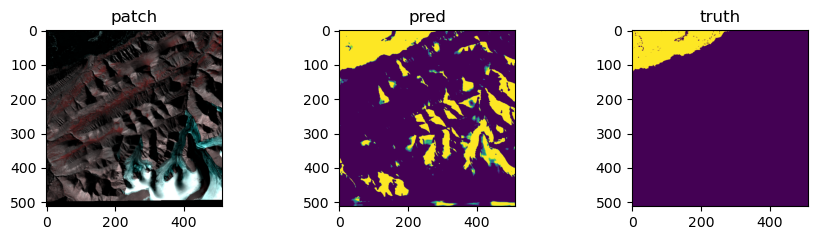

Ep960: tra-> Loss:0.041,Oa:0.984,Miou:0.928,                                 time:3.6s
Ep961: tra-> Loss:0.042,Oa:0.984,Miou:0.917, val-> Loss:0.3509,Oa:0.8981, Miou:0.6564,time:5.5s
Ep962: tra-> Loss:0.042,Oa:0.984,Miou:0.923,                                 time:3.5s
Ep963: tra-> Loss:0.040,Oa:0.985,Miou:0.931, val-> Loss:0.3780,Oa:0.9007, Miou:0.6649,time:5.6s
Ep964: tra-> Loss:0.041,Oa:0.985,Miou:0.929,                                 time:3.4s
Ep965: tra-> Loss:0.042,Oa:0.984,Miou:0.919, val-> Loss:0.5228,Oa:0.8966, Miou:0.6537,time:5.5s
Ep966: tra-> Loss:0.046,Oa:0.982,Miou:0.915,                                 time:3.5s
Ep967: tra-> Loss:0.039,Oa:0.985,Miou:0.931, val-> Loss:0.3781,Oa:0.8980, Miou:0.6566,time:5.5s
Ep968: tra-> Loss:0.046,Oa:0.984,Miou:0.922,                                 time:3.5s
Ep969: tra-> Loss:0.042,Oa:0.984,Miou:0.919, val-> Loss:0.3051,Oa:0.9011, Miou:0.6650,time:5.6s
Ep970: tra-> Loss:0.048,Oa:0.981,Miou:0.907,                                 time:3.6

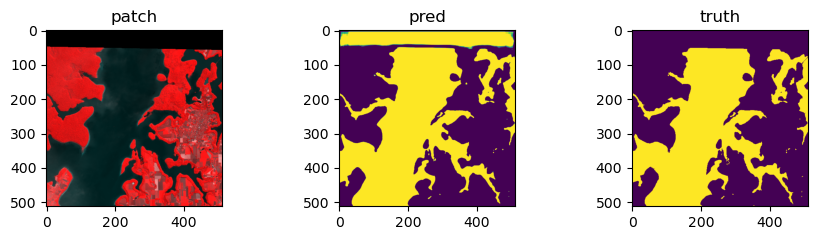

Ep980: tra-> Loss:0.044,Oa:0.984,Miou:0.925,                                 time:3.7s
Ep981: tra-> Loss:0.043,Oa:0.984,Miou:0.926, val-> Loss:0.2637,Oa:0.9030, Miou:0.6701,time:5.6s
Ep982: tra-> Loss:0.041,Oa:0.985,Miou:0.929,                                 time:3.6s
Ep983: tra-> Loss:0.040,Oa:0.984,Miou:0.917, val-> Loss:0.4288,Oa:0.9002, Miou:0.6597,time:5.6s
Ep984: tra-> Loss:0.041,Oa:0.984,Miou:0.929,                                 time:3.5s
Ep985: tra-> Loss:0.043,Oa:0.983,Miou:0.921, val-> Loss:0.3662,Oa:0.9012, Miou:0.6657,time:5.6s
Ep986: tra-> Loss:0.036,Oa:0.986,Miou:0.933,                                 time:3.5s
Ep987: tra-> Loss:0.039,Oa:0.985,Miou:0.929, val-> Loss:0.1104,Oa:0.9545, Miou:0.8119,time:5.6s
Ep988: tra-> Loss:0.045,Oa:0.983,Miou:0.919,                                 time:3.5s
Ep989: tra-> Loss:0.041,Oa:0.985,Miou:0.921, val-> Loss:0.3692,Oa:0.8992, Miou:0.6585,time:5.6s
Ep990: tra-> Loss:0.040,Oa:0.985,Miou:0.930,                                 time:3.5

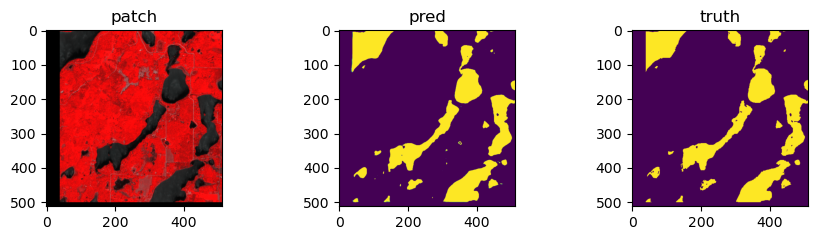

In [ ]:
if __name__ == '__main__':
    metrics = train_loops(model=model,  
                    epoches=1000,   
                    loss_fn=bce_loss,   
                    optimizer=optimizer,  
                    tra_loader=tra_loader,   
                    val_loader=val_loader,   
                    # lr_scheduler=lr_scheduler,   
                    device=device) 



In [ ]:
# torch.save(model.state_dict(), f'model/trained/{model_name}_.pth')
# ## metrics saving
# path_metrics = f'model/trained/{model_name}_training_metrics.csv'
# metrics_df = pd.DataFrame(metrics)
# metrics_df.to_csv(path_metrics, index=False, sep=',')  


: 